# Preparation

**Import Libraries**

In [1]:
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pylidc as pl
import SimpleITK as sitk
from scipy import ndimage as ndi
from scipy.ndimage import binary_dilation, binary_erosion, center_of_mass
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border

/home/dityanugroho/miniforge3/envs/nodule_py310/lib/python3.10/site-packages/pylidc/__init__.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as _pr


**Notebook Settings**

In [2]:
%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# Use the same lung-window HU range for both datasets.
LUNG_WINDOW = (-1400, 200)

**Constants**

In [3]:
# Select the LIDC-IDRI patient available on this device.
LIDC_PATIENT_ID = "LIDC-IDRI-0001"

# Replace this path if a different LNDb scan is used.
LNDB_MHD_PATH = Path("../000_dataset/lndb/data/LNDb-0001.mhd")

# Fixed lung-window parameters shared by LIDC-IDRI and LNDb.
WINDOW_LEVEL = -600.0
WINDOW_WIDTH = 1600.0

# Lung parenchyma segmentation parameters.
HU_THRESHOLD = -320
NUM_LARGEST_COMPONENTS = 4
TRACHEA_AREA_THRESHOLD = 0.0069
DILATION_ITERATIONS = 5

# Reduce the outer boundary added by dilation.
EROSION_ITERATIONS = 5

# Apply a 3 x 3 median filter independently to each axial slice.
MEDIAN_FILTER_SIZE = (1, 3, 3)

# Change a stage to False to pass its input mask through unchanged.
STAGE_ENABLED = OrderedDict(
    [
        ("1. Threshold HU", True),
        ("2. Remove border objects", True),
        ("3. Keep largest components", True),
        ("4. Fill holes", True),
        ("5. Remove trachea", True),
        ("6. Remove table/artifacts", False),
        ("7. Binary dilation", True),
    ]
)

# Step 1: Convert CT Scans to NumPy

Convert the LIDC-IDRI DICOM scan and LNDb MHD scan into NumPy arrays with the dimension `[slices, height, width]`. The original Hounsfield Unit values are retained for segmentation and filtering.

**LIDC-IDRI CT Scan (DICOM File) to NumPy Format**

In [4]:
# On Ubuntu, pylidc reads the DICOM root from ~/.pylidcrc.
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == LIDC_PATIENT_ID).first()
lidc_volume = scan.to_volume()

# pylidc returns (height, width, slices); use (slices, height, width).
lidc_volume = np.transpose(lidc_volume, (2, 0, 1)).astype(np.int16)

print(f"Shape: {lidc_volume.shape} | dtype: {lidc_volume.dtype}")

Loading dicom files ... This may take a moment.
Shape: (133, 512, 512) | dtype: int16


**LNDb CT Scan (.mhd File) to NumPy Format**

In [5]:
lndb_image = sitk.ReadImage(str(LNDB_MHD_PATH))

# SimpleITK returns the volume as (slices, height, width).
lndb_volume = sitk.GetArrayFromImage(lndb_image).astype(np.int16)

print(f"Shape: {lndb_volume.shape} | dtype: {lndb_volume.dtype}")

Shape: (328, 512, 512) | dtype: int16


In [6]:
ct_volumes = OrderedDict(
    [
        ("LIDC-IDRI", lidc_volume),
        ("LNDb", lndb_volume),
    ]
)

**CT Volume and Intensity Histogram**

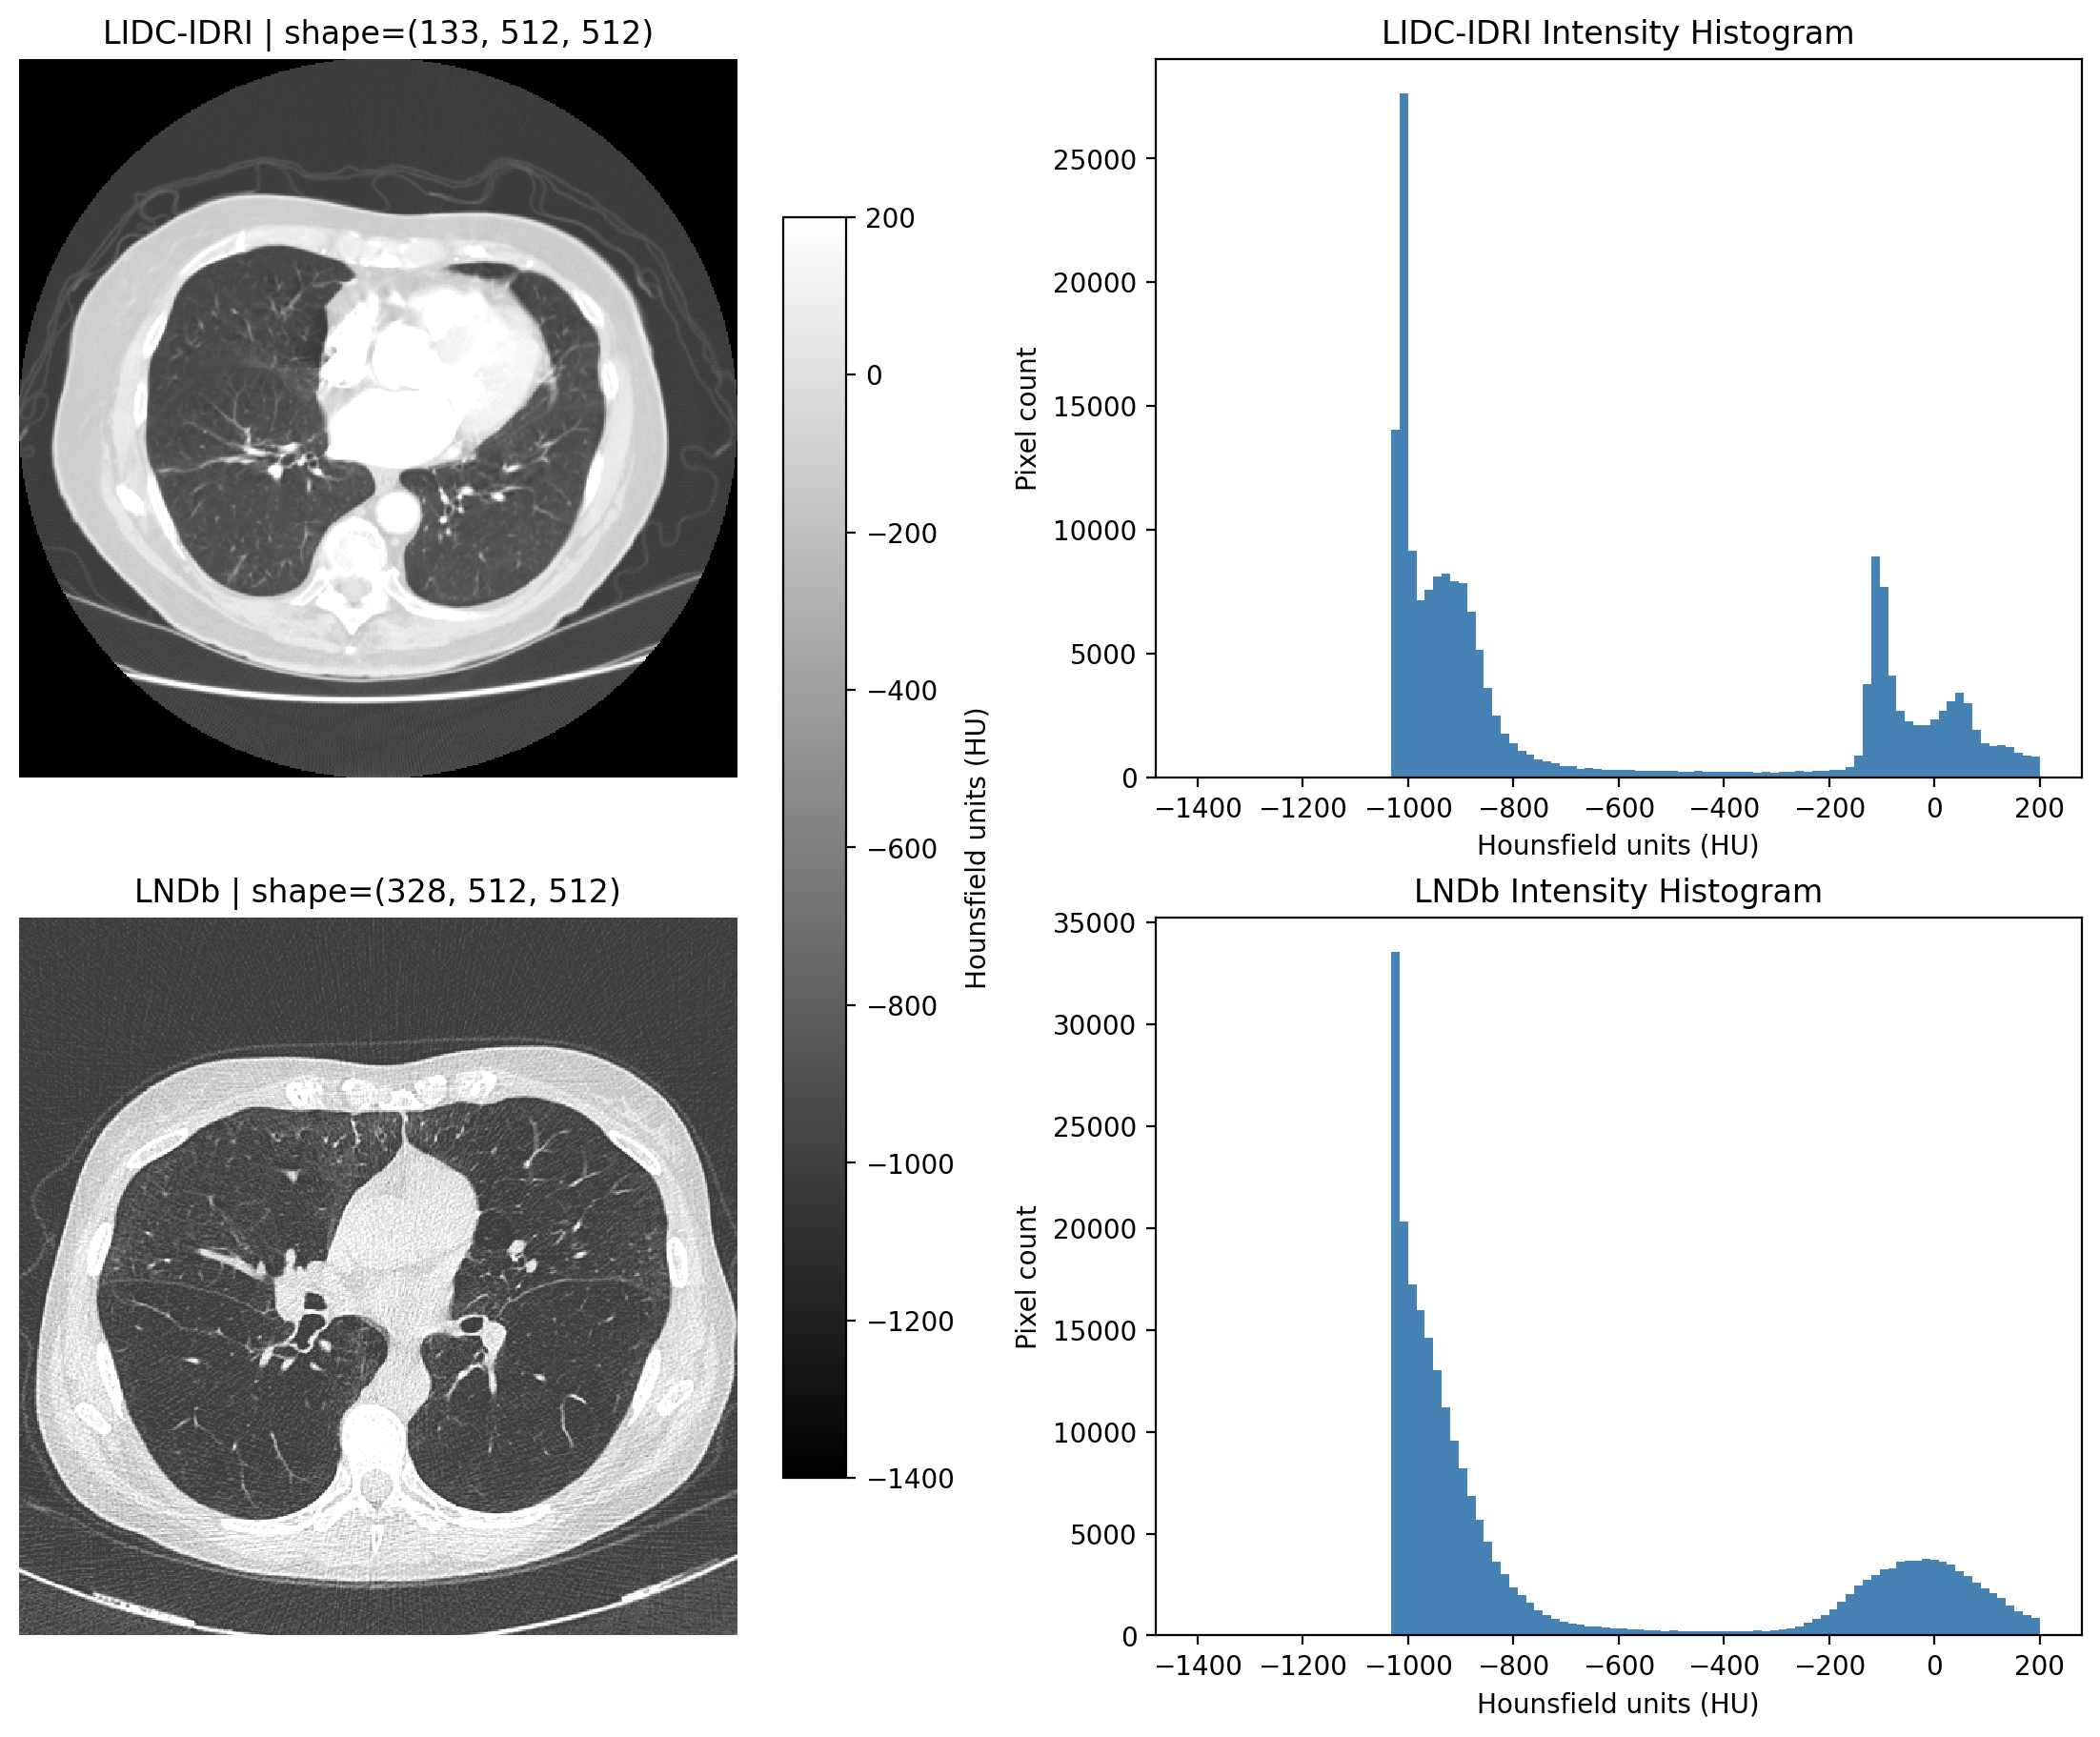

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for row, (dataset_name, volume) in enumerate(ct_volumes.items()):
    image_axis, histogram_axis = axes[row]

    # Use the middle axial slice for both the image and its histogram.
    middle_slice = volume.shape[0] // 2
    slice_image = volume[middle_slice]

    image = image_axis.imshow(
        slice_image,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    image_axis.set_title(f"{dataset_name} | shape={volume.shape}")
    image_axis.axis("off")

    histogram_axis.hist(
        slice_image.ravel(),
        bins=100,
        range=LUNG_WINDOW,
        color="steelblue",
    )
    histogram_axis.set_title(f"{dataset_name} Intensity Histogram")
    histogram_axis.set_xlabel("Hounsfield units (HU)")
    histogram_axis.set_ylabel("Pixel count")

fig.colorbar(image, ax=axes[:, 0], shrink=0.8, label="Hounsfield units (HU)")
plt.show()

# Step 2: Lung Parenchyma Segmentation

Create a binary lung mask from the original CT values in Hounsfield Units. The mask is produced by HU thresholding, border removal, connected-component selection, hole filling, trachea removal, optional table removal, and dilation.

Set a value in `STAGE_ENABLED` to `False` to skip that operation. A skipped stage passes the previous mask through unchanged.

**Segmentation Operations**

In [8]:
def threshold_lung(slice_image: np.ndarray) -> np.ndarray:
    return slice_image < HU_THRESHOLD


def remove_border_objects(mask: np.ndarray) -> np.ndarray:
    return clear_border(mask)


def keep_largest_components(mask: np.ndarray) -> np.ndarray:
    labeled = label(mask)
    regions = regionprops(labeled)

    if len(regions) == 0:
        return np.zeros_like(mask, dtype=bool)

    output = np.zeros_like(mask, dtype=bool)
    areas = [region.area for region in regions]
    sorted_indices = np.argsort(areas)[::-1]

    for idx in sorted_indices[:NUM_LARGEST_COMPONENTS]:
        output[tuple(regions[idx].coords.T)] = True

    return output


def fill_holes(mask: np.ndarray) -> np.ndarray:
    return ndi.binary_fill_holes(mask)


def remove_trachea(mask: np.ndarray) -> np.ndarray:
    output = mask.copy()
    labeled = label(mask)
    regions = regionprops(labeled)
    image_area = mask.shape[0] * mask.shape[1]

    for region in regions:
        area_ratio = region.area / image_area

        if area_ratio < TRACHEA_AREA_THRESHOLD:
            output[tuple(region.coords.T)] = False

    return output


def remove_table(mask: np.ndarray) -> np.ndarray:
    output = mask.copy()
    labeled = label(mask)
    component_ids = np.unique(labeled)[1:]

    for component_id in component_ids:
        center_y = center_of_mass(labeled == component_id)[0]

        if center_y < 0.30 * mask.shape[0]:
            output[labeled == component_id] = False
        elif center_y > 0.60 * mask.shape[0]:
            output[labeled == component_id] = False

    return output


def dilate_mask(mask: np.ndarray) -> np.ndarray:
    return binary_dilation(mask, iterations=DILATION_ITERATIONS)


STAGE_FUNCTIONS = OrderedDict(
    [
        ("1. Threshold HU", threshold_lung),
        ("2. Remove border objects", remove_border_objects),
        ("3. Keep largest components", keep_largest_components),
        ("4. Fill holes", fill_holes),
        ("5. Remove trachea", remove_trachea),
        ("6. Remove table/artifacts", remove_table),
        ("7. Binary dilation", dilate_mask),
    ]
)

**Apply Each Stage to Representative Slices**

In [9]:
def collect_stage_masks(
    slice_image: np.ndarray,
    stage_config: OrderedDict,
    initial_mask: np.ndarray | None = None,
) -> tuple[OrderedDict, OrderedDict]:
    if list(stage_config) != list(STAGE_FUNCTIONS):
        raise ValueError("stage_config must contain the seven stages in order.")

    stage_masks = OrderedDict()
    stage_status = OrderedDict()
    mask = None

    # Apply enabled stages in the same order as the batch pipeline.
    for stage_name, stage_function in STAGE_FUNCTIONS.items():
        is_enabled = bool(stage_config[stage_name])

        if stage_name == "1. Threshold HU":
            if is_enabled:
                mask = stage_function(slice_image)
            elif initial_mask is not None:
                if initial_mask.shape != slice_image.shape:
                    raise ValueError(
                        "initial_mask and slice_image must have the same shape."
                    )

                unique_values = np.unique(initial_mask)
                if not np.all(np.isin(unique_values, [0, 1])):
                    raise ValueError(
                        "initial_mask must be binary with values 0 and 1."
                    )

                mask = np.asarray(initial_mask, dtype=bool).copy()
            else:
                raise ValueError(
                    "HU thresholding cannot be skipped for raw HU input unless "
                    "an alternative binary initial_mask is provided."
                )
        elif is_enabled:
            mask = stage_function(mask)

        stage_masks[stage_name] = mask.copy()
        stage_status[stage_name] = "APPLIED" if is_enabled else "SKIPPED"

    return stage_masks, stage_status


# Provide a binary mask here only when HU thresholding is disabled.
INITIAL_MASKS = {
    "LIDC-IDRI": None,
    "LNDb": None,
}

segmentation_results = OrderedDict()

for dataset_name, volume in ct_volumes.items():
    slice_index = volume.shape[0] // 2
    slice_image = volume[slice_index]
    stage_masks, stage_status = collect_stage_masks(
        slice_image=slice_image,
        stage_config=STAGE_ENABLED,
        initial_mask=INITIAL_MASKS[dataset_name],
    )
    segmentation_results[dataset_name] = (
        slice_index,
        slice_image,
        stage_masks,
        stage_status,
    )

**Visualization of Each Segmentation Stage**

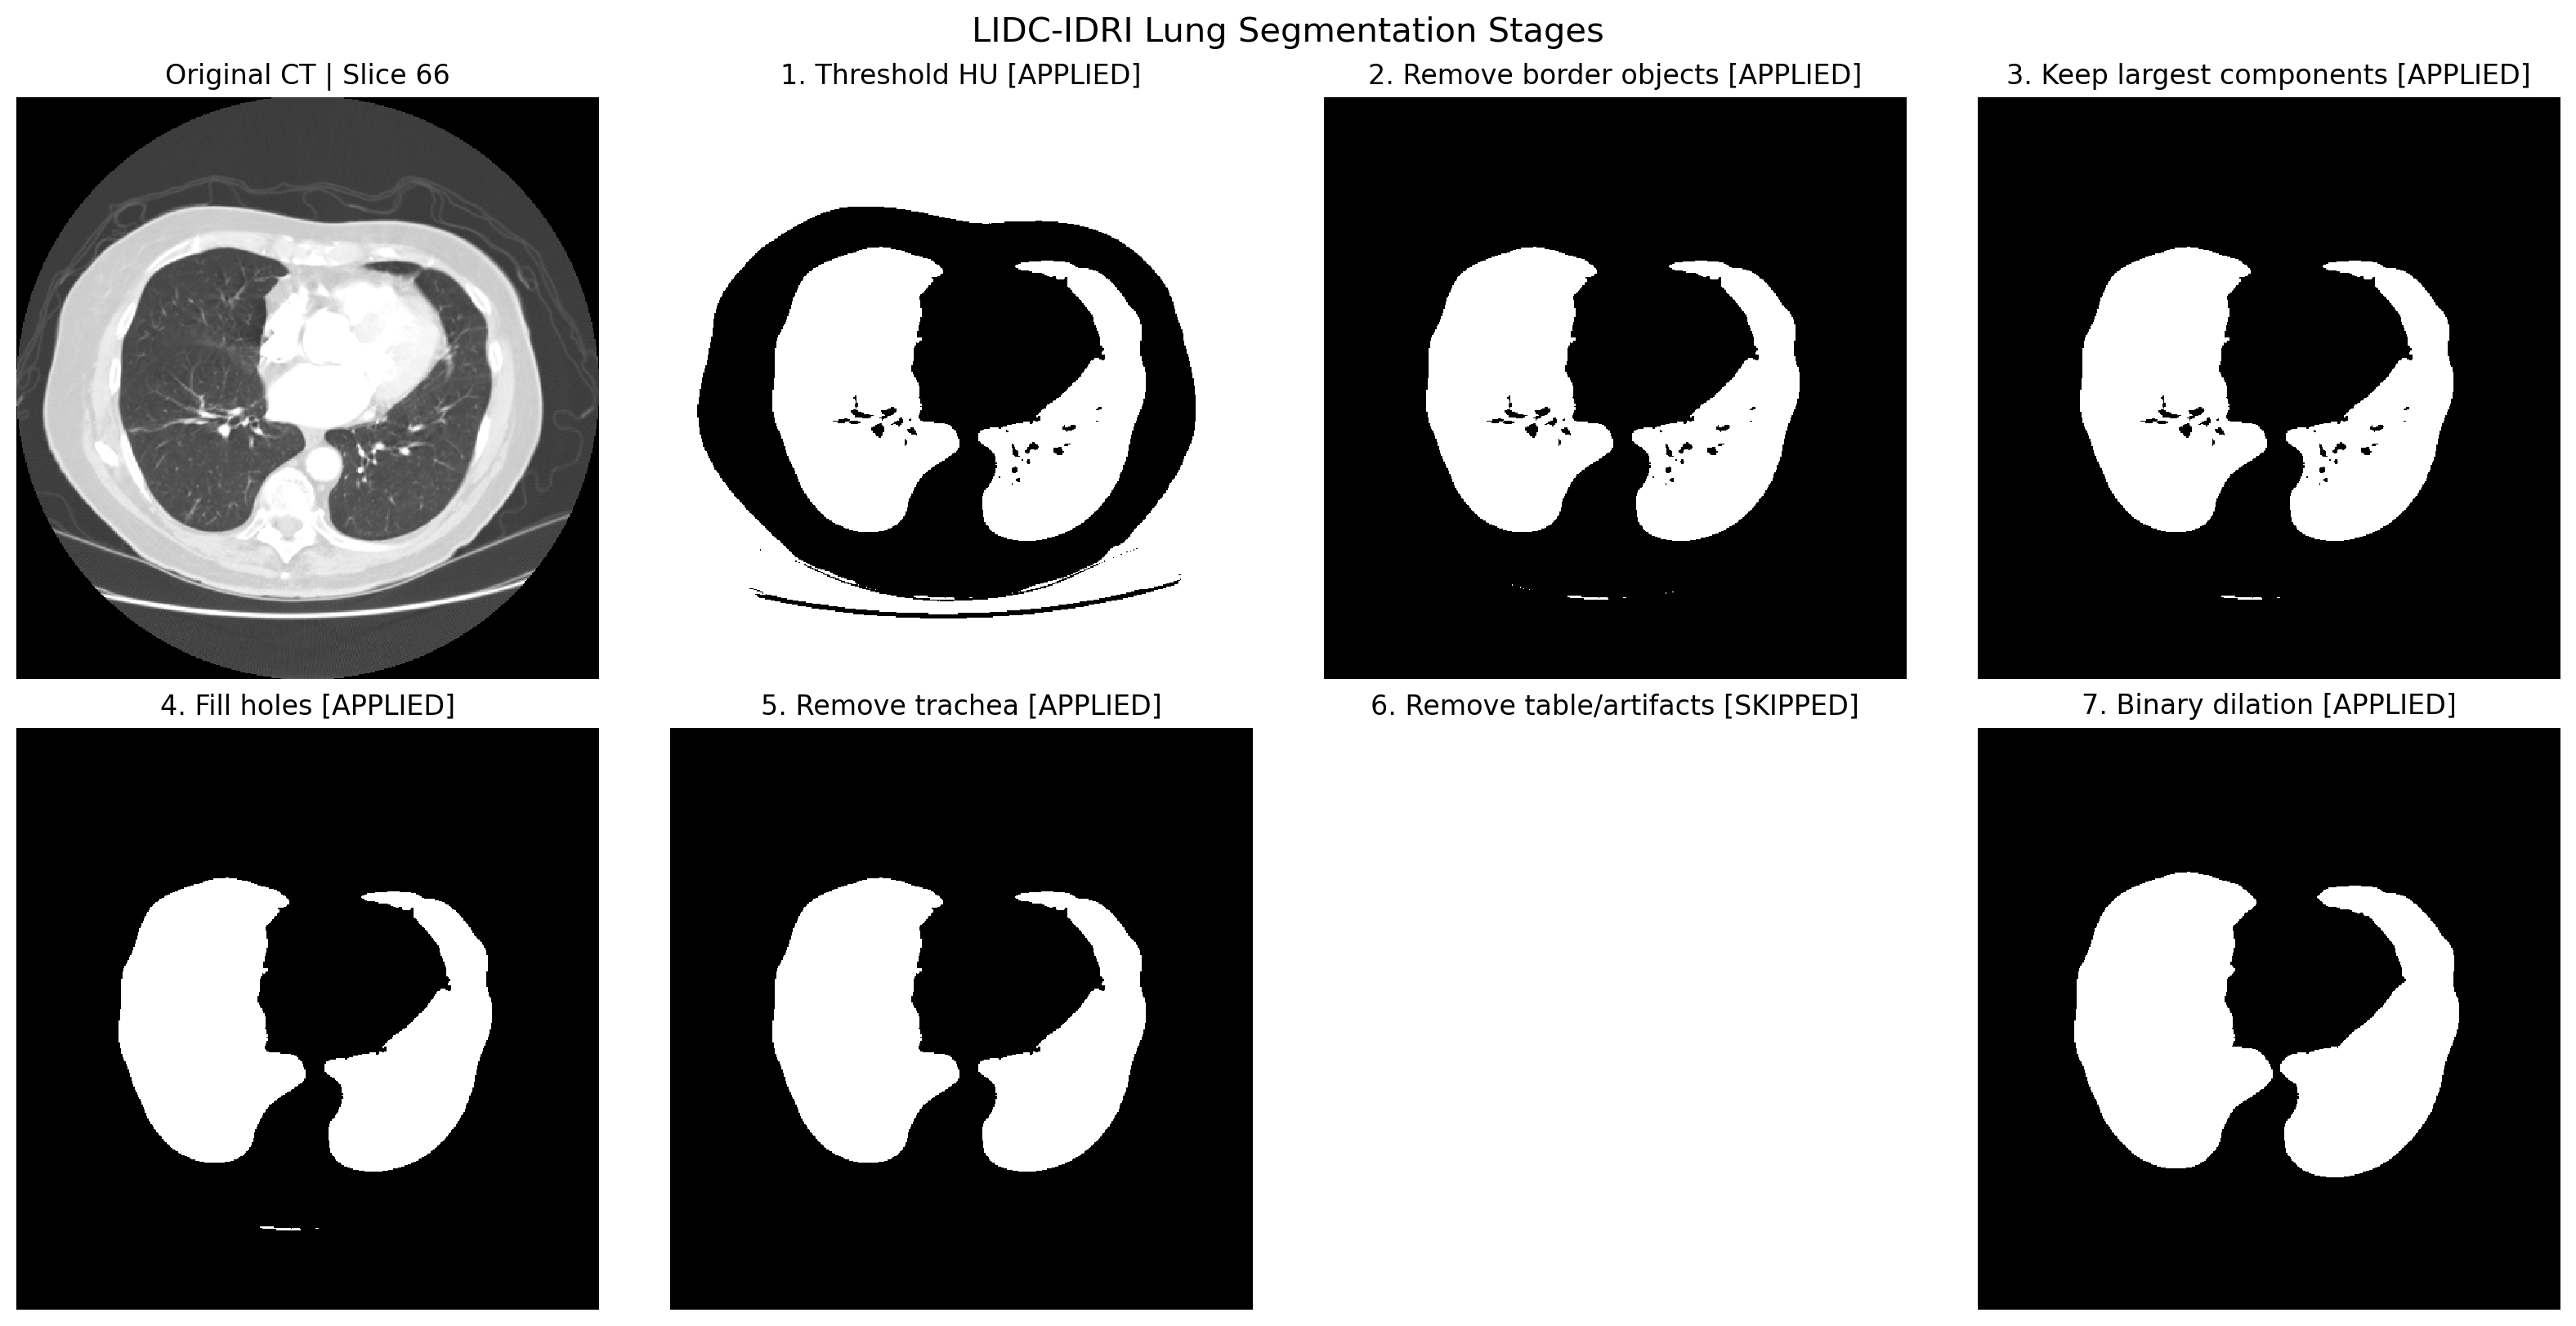

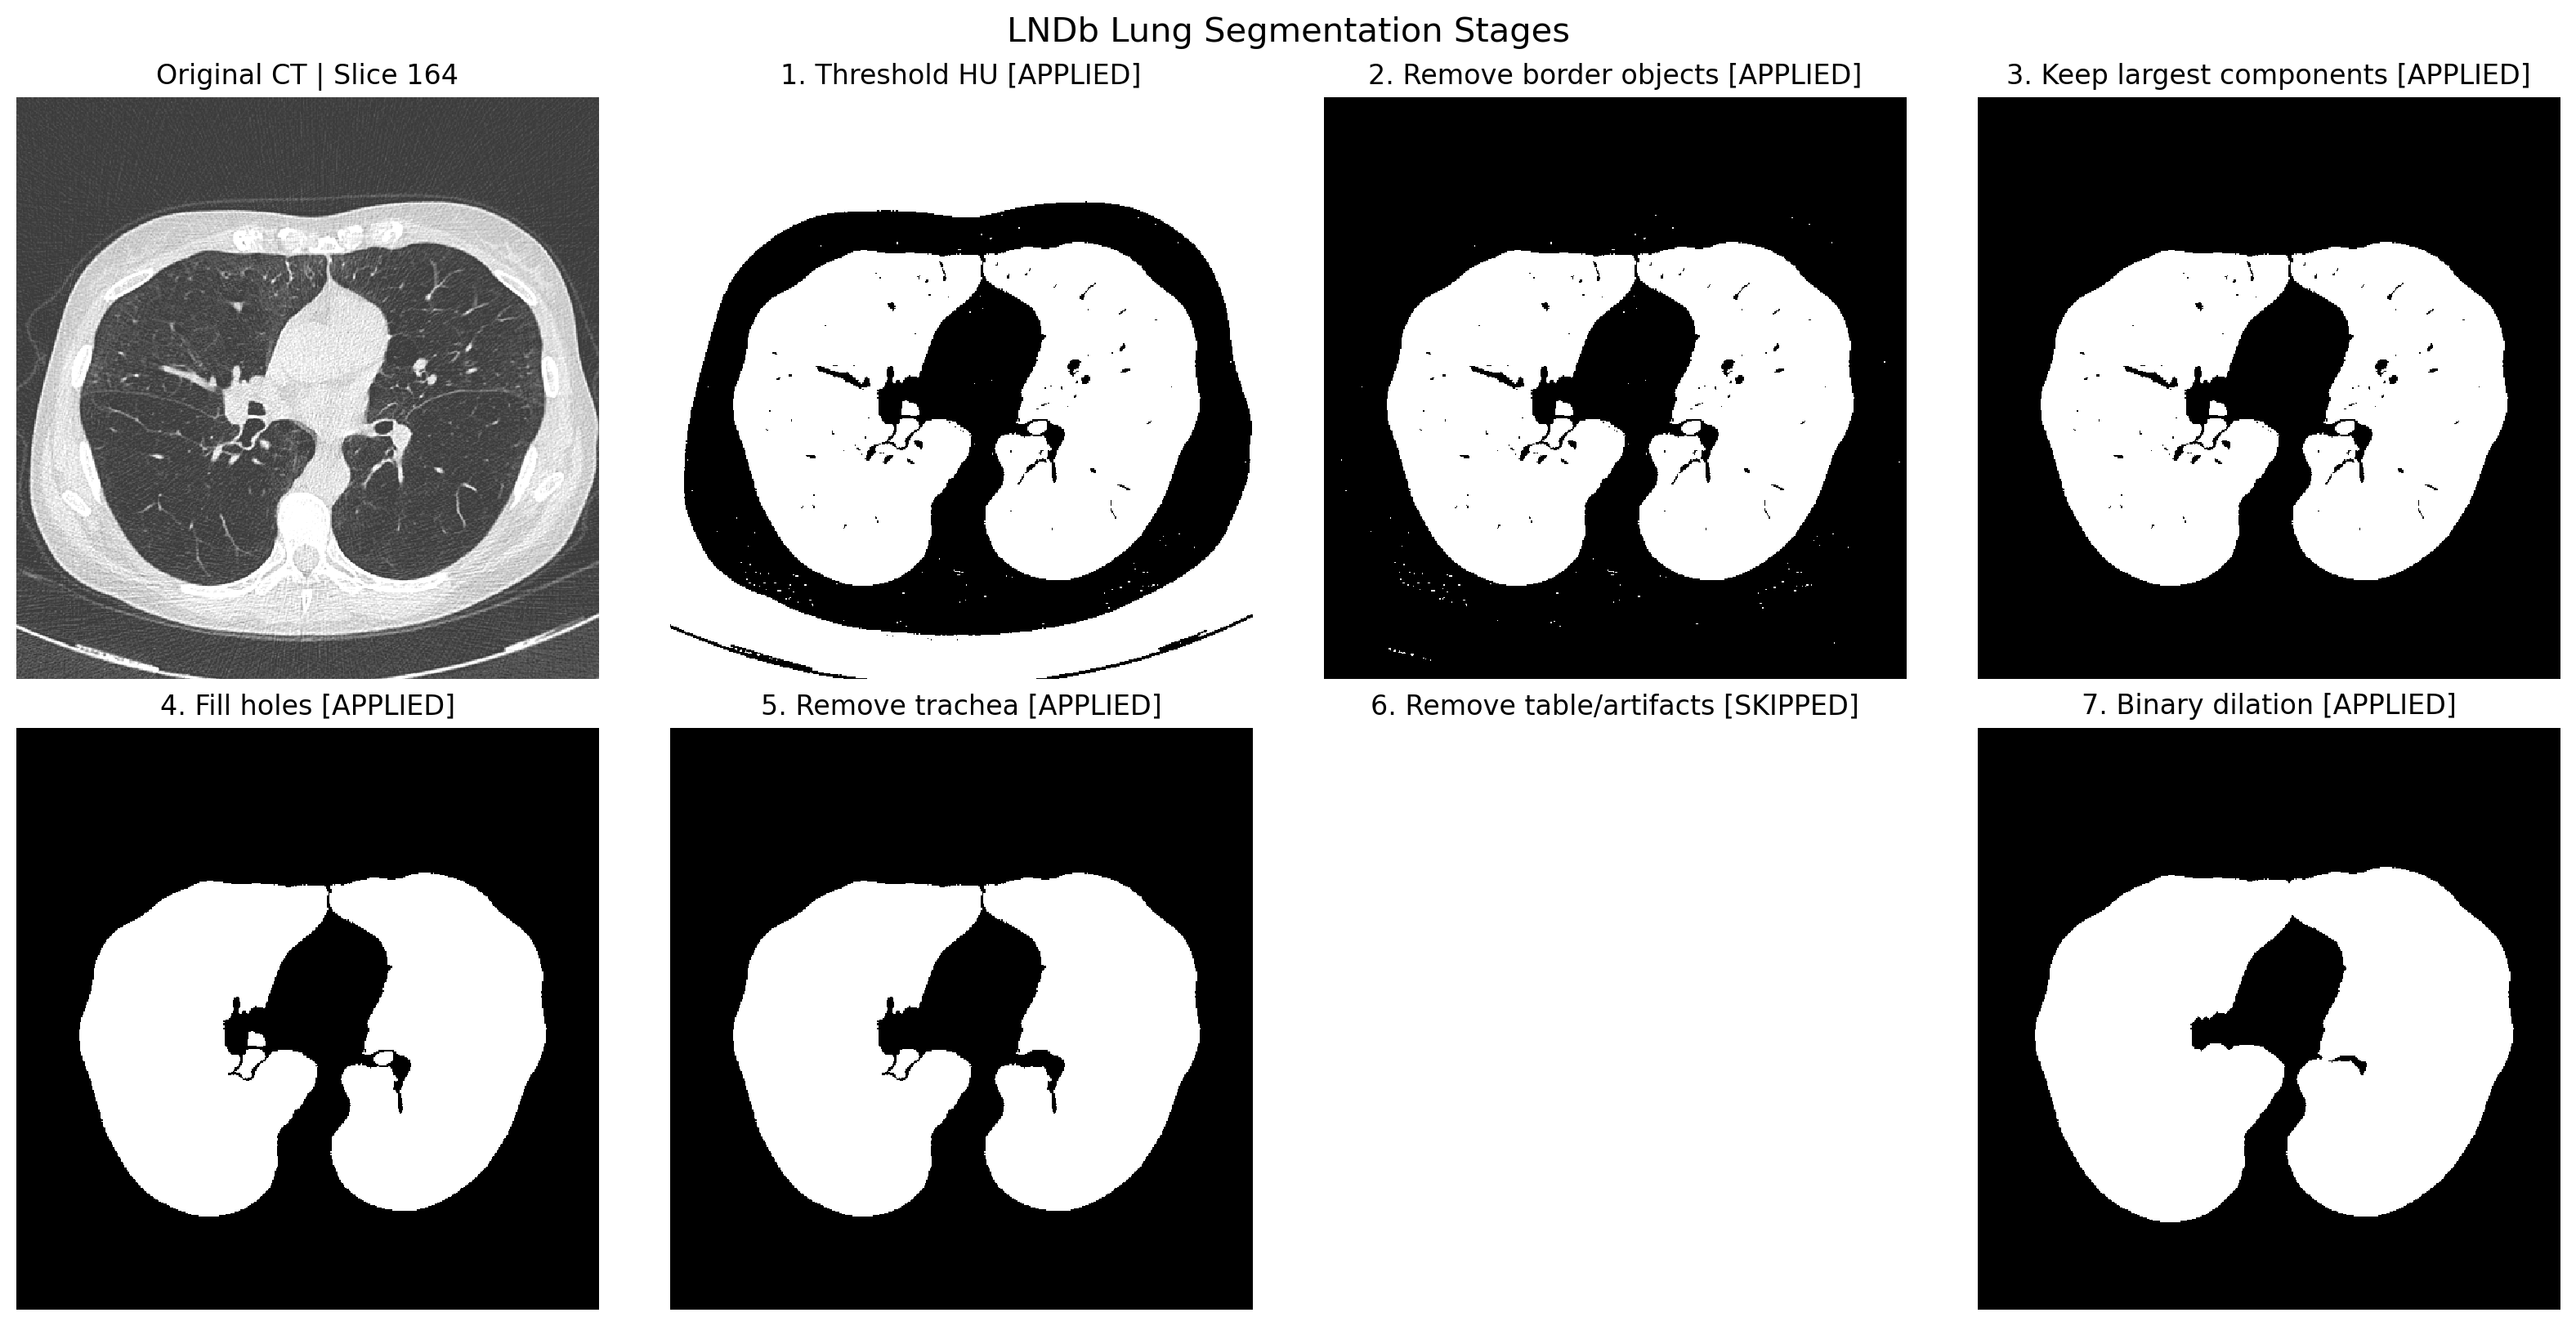

In [10]:
for dataset_name, (
    slice_index,
    slice_image,
    stage_masks,
    stage_status,
) in segmentation_results.items():
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
    axes = axes.ravel()

    axes[0].imshow(
        slice_image,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[0].set_title(f"Original CT | Slice {slice_index}")

    for axis, (stage_name, stage_mask) in zip(axes[1:], stage_masks.items()):
        status = stage_status[stage_name]

        # Keep the stage title but leave the panel empty when it is skipped.
        if status == "APPLIED":
            axis.imshow(stage_mask, vmin=0, vmax=1)

        axis.set_title(f"{stage_name} [{status}]")

    for axis in axes:
        axis.axis("off")

    fig.suptitle(f"{dataset_name} Lung Segmentation Stages", fontsize=15)
    plt.show()

**Final Lung Mask and Lung Parenchyma Area**

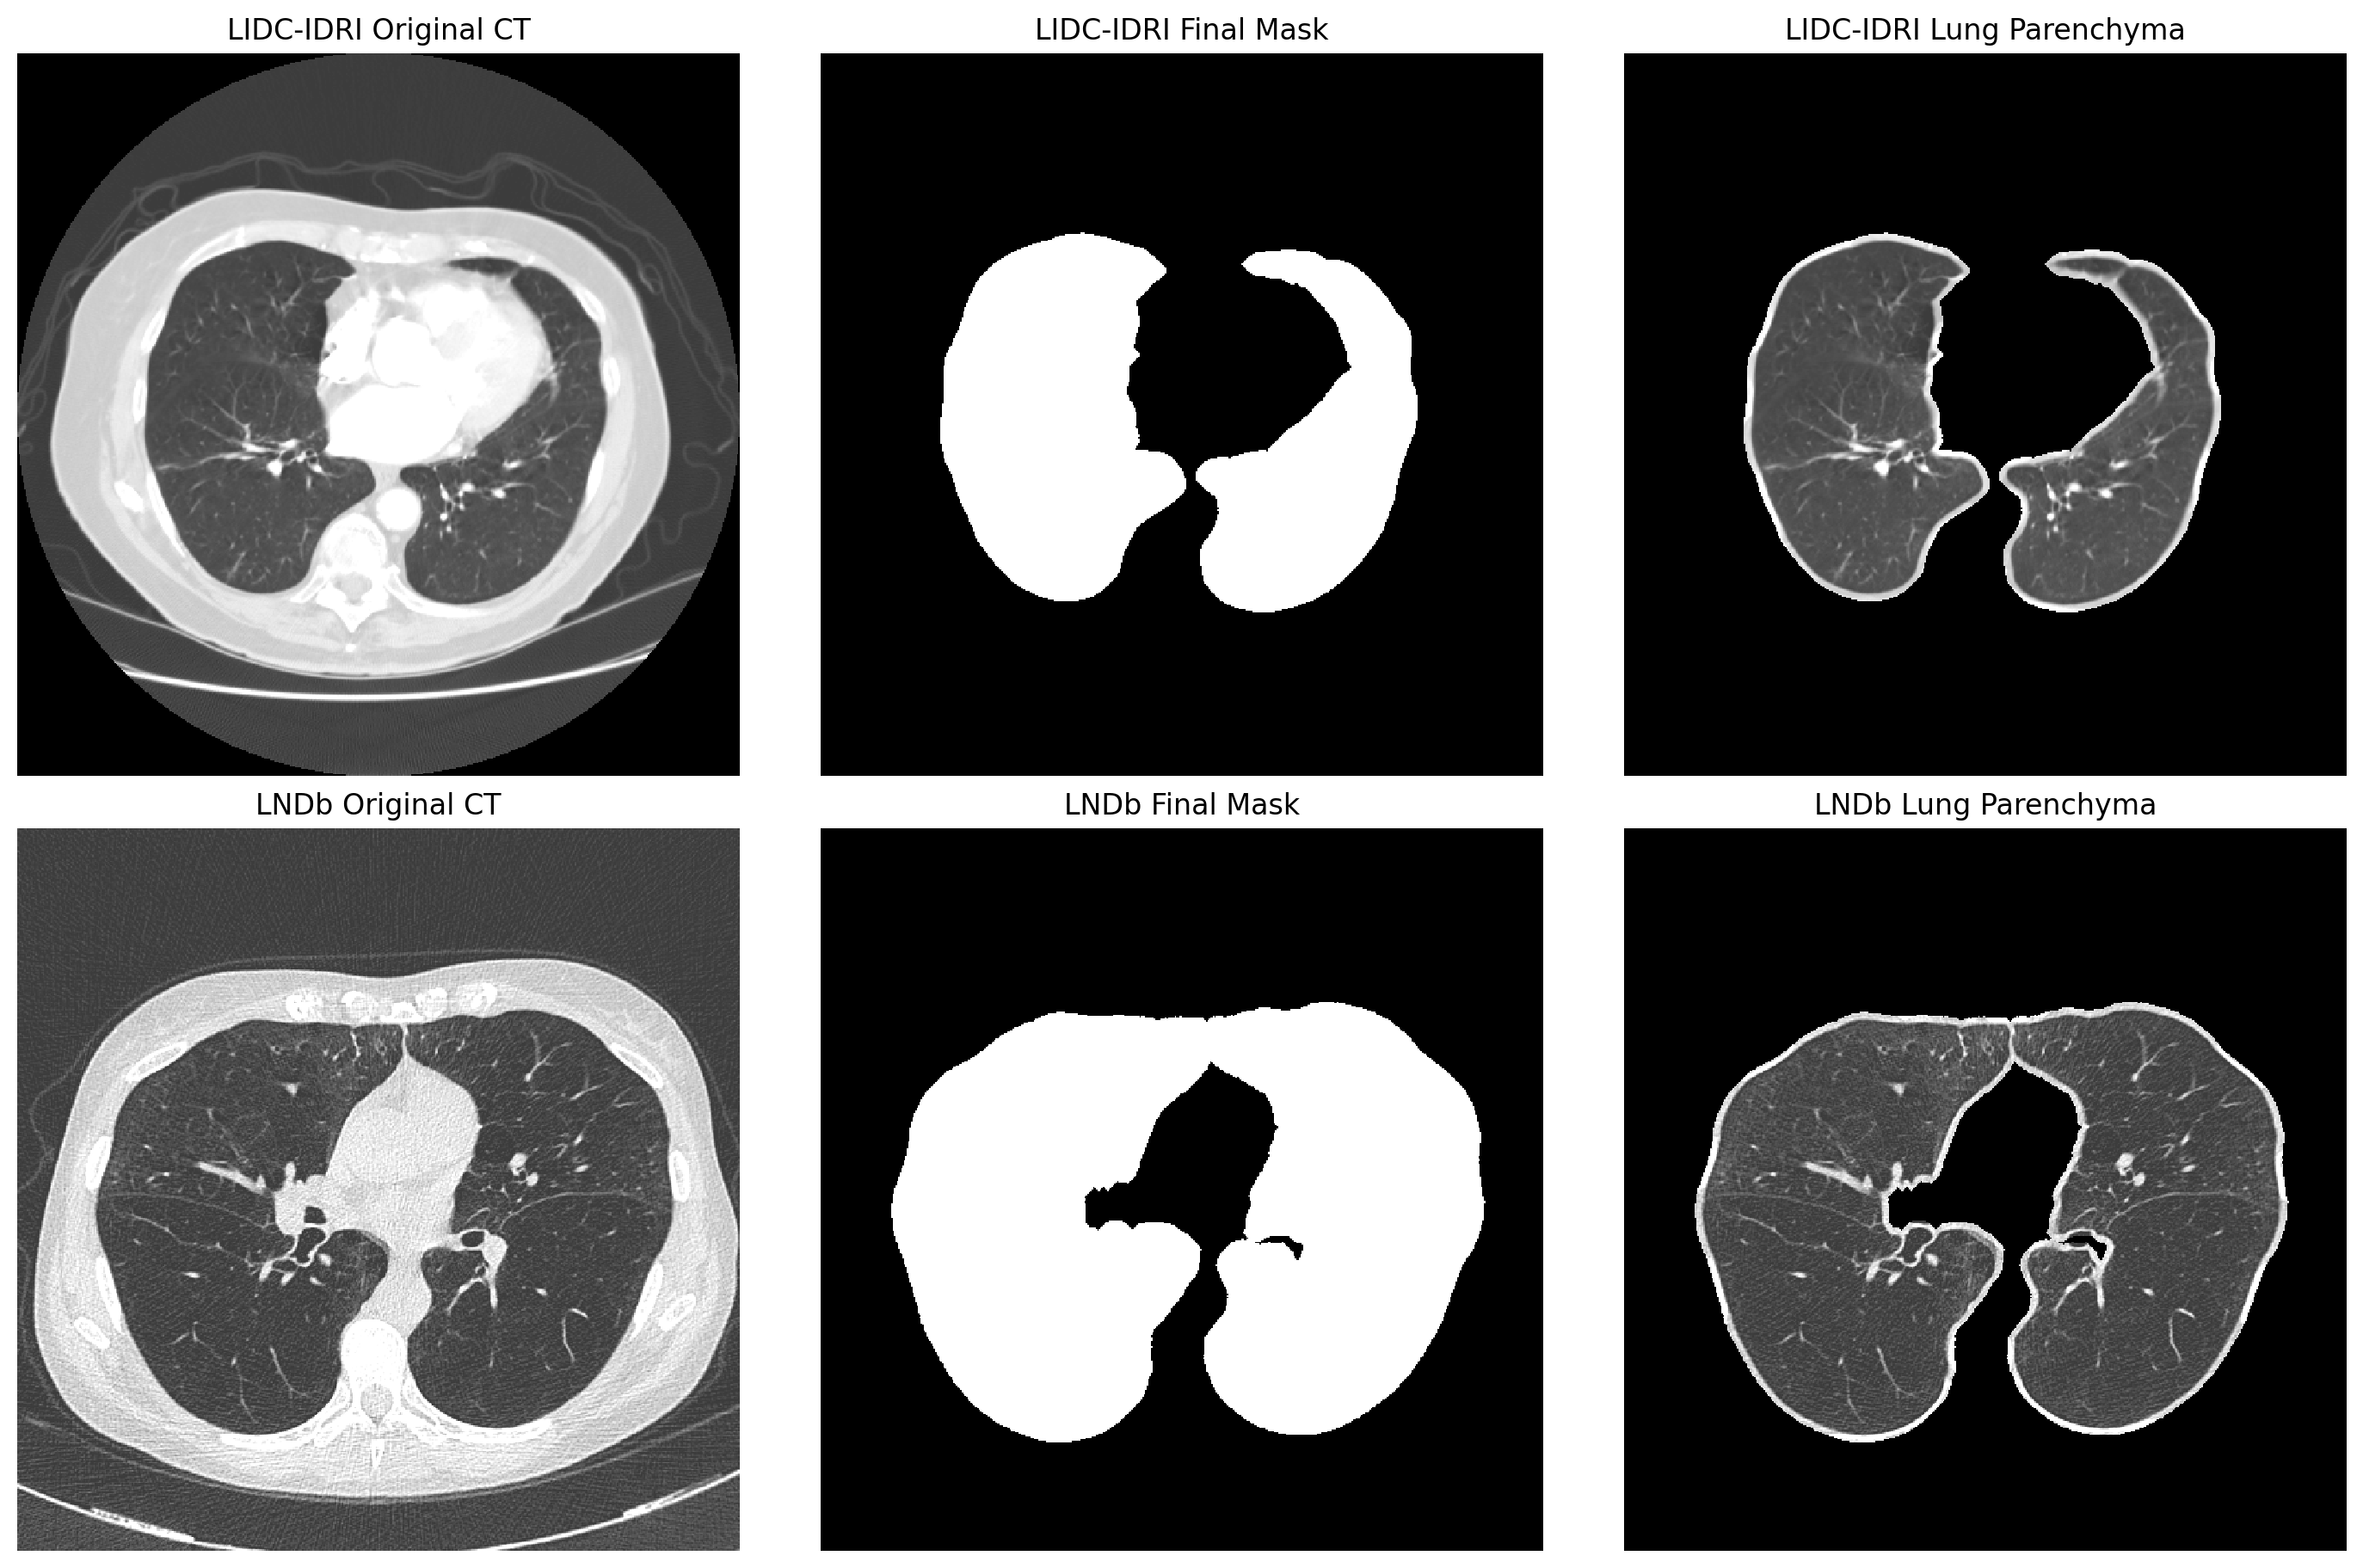

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

for row, (dataset_name, (_, slice_image, stage_masks, _)) in enumerate(
    segmentation_results.items()
):
    final_mask = stage_masks["7. Binary dilation"]
    lung_parenchyma = np.where(final_mask, slice_image, LUNG_WINDOW[0])

    axes[row, 0].imshow(
        slice_image,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 0].set_title(f"{dataset_name} Original CT")

    axes[row, 1].imshow(final_mask, vmin=0, vmax=1)
    axes[row, 1].set_title(f"{dataset_name} Final Mask")

    axes[row, 2].imshow(
        lung_parenchyma,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 2].set_title(f"{dataset_name} Lung Parenchyma")

for axis in axes.ravel():
    axis.axis("off")

plt.show()

**Lung Parenchyma and Intensity Histogram**

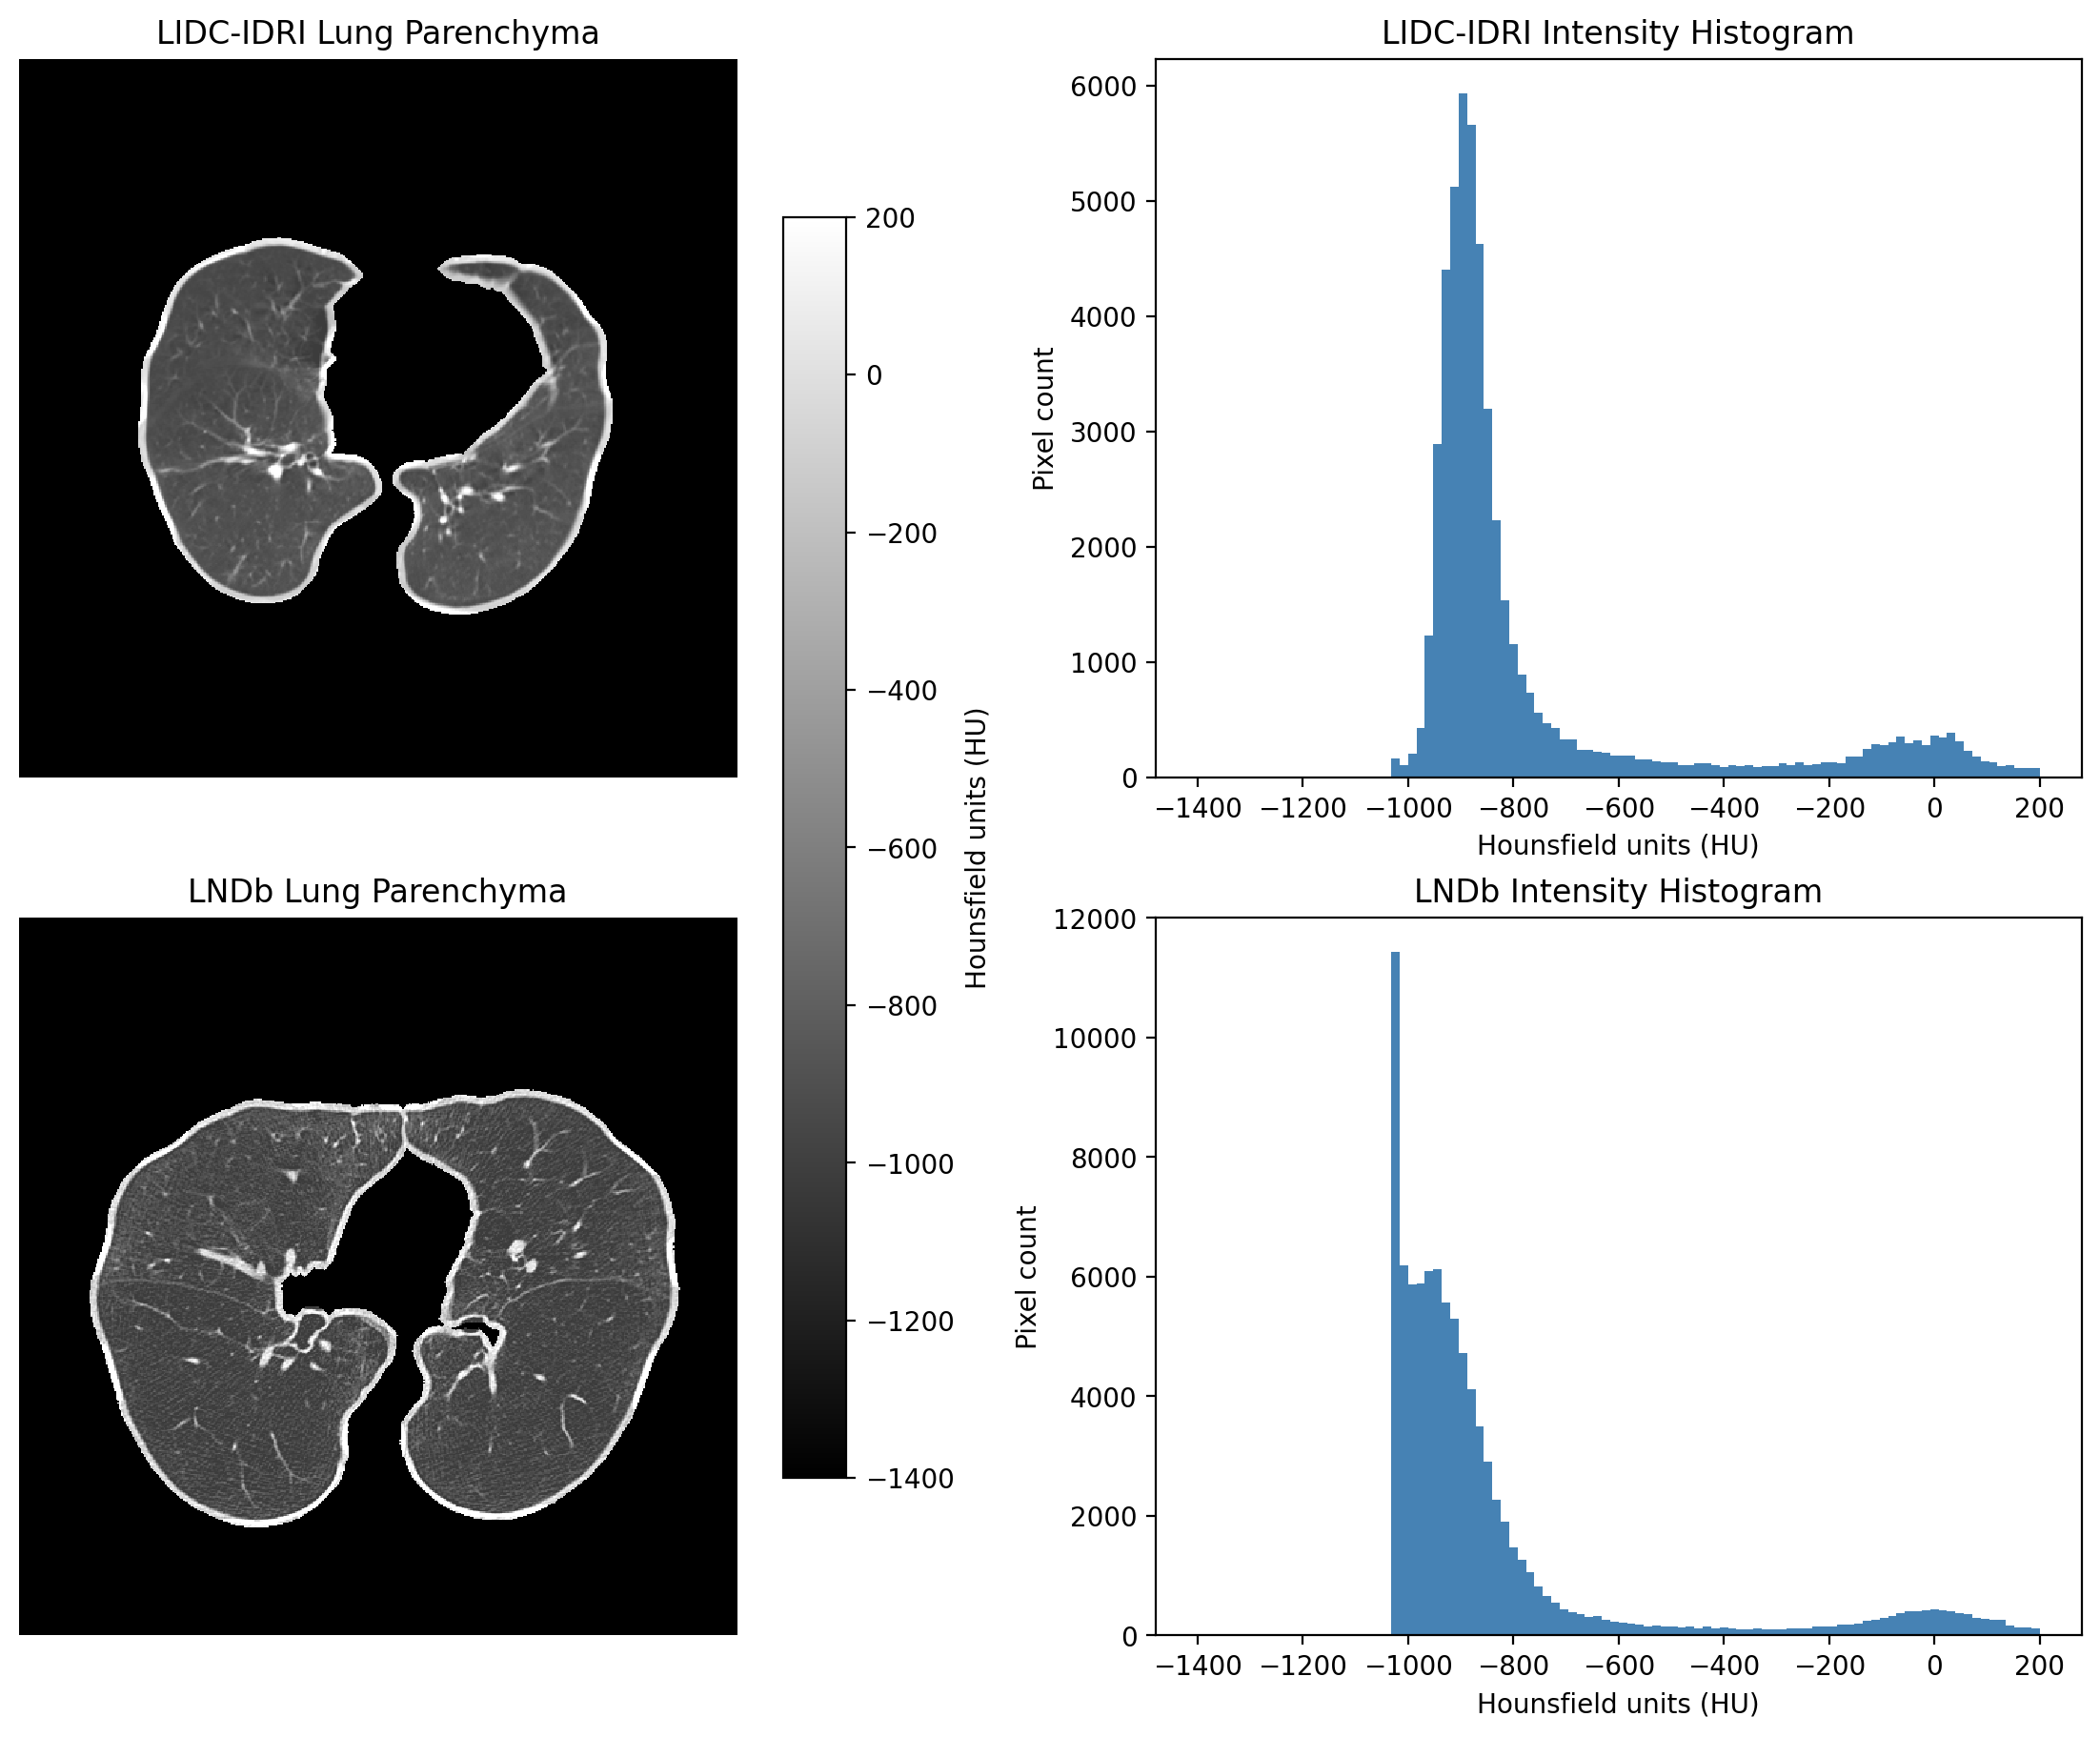

In [12]:
parenchyma_examples = []

for dataset_name, (_, slice_image, stage_masks, _) in segmentation_results.items():
    final_mask = stage_masks["7. Binary dilation"]
    lung_parenchyma = np.where(final_mask, slice_image, LUNG_WINDOW[0])

    # Exclude the artificial background from the intensity histogram.
    parenchyma_intensities = slice_image[final_mask]
    parenchyma_examples.append(
        (dataset_name, lung_parenchyma, parenchyma_intensities)
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for row, (dataset_name, lung_parenchyma, intensities) in enumerate(
    parenchyma_examples
):
    image_axis, histogram_axis = axes[row]

    image = image_axis.imshow(
        lung_parenchyma,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    image_axis.set_title(f"{dataset_name} Lung Parenchyma")
    image_axis.axis("off")

    histogram_axis.hist(
        intensities,
        bins=100,
        range=LUNG_WINDOW,
        color="steelblue",
    )
    histogram_axis.set_title(f"{dataset_name} Intensity Histogram")
    histogram_axis.set_xlabel("Hounsfield units (HU)")
    histogram_axis.set_ylabel("Pixel count")

fig.colorbar(image, ax=axes[:, 0], shrink=0.8, label="Hounsfield units (HU)")
plt.show()

# Step 3: Binary Erosion

Apply binary erosion after dilation to reduce the outer boundary of the lung mask. Each iteration removes one layer of boundary pixels.

In [13]:
eroded_masks = OrderedDict()

for dataset_name, (_, _, stage_masks, _) in segmentation_results.items():
    dilated_mask = stage_masks["7. Binary dilation"]
    eroded_masks[dataset_name] = binary_erosion(
        dilated_mask,
        iterations=EROSION_ITERATIONS,
    )

**Visualization Before and After Binary Erosion**

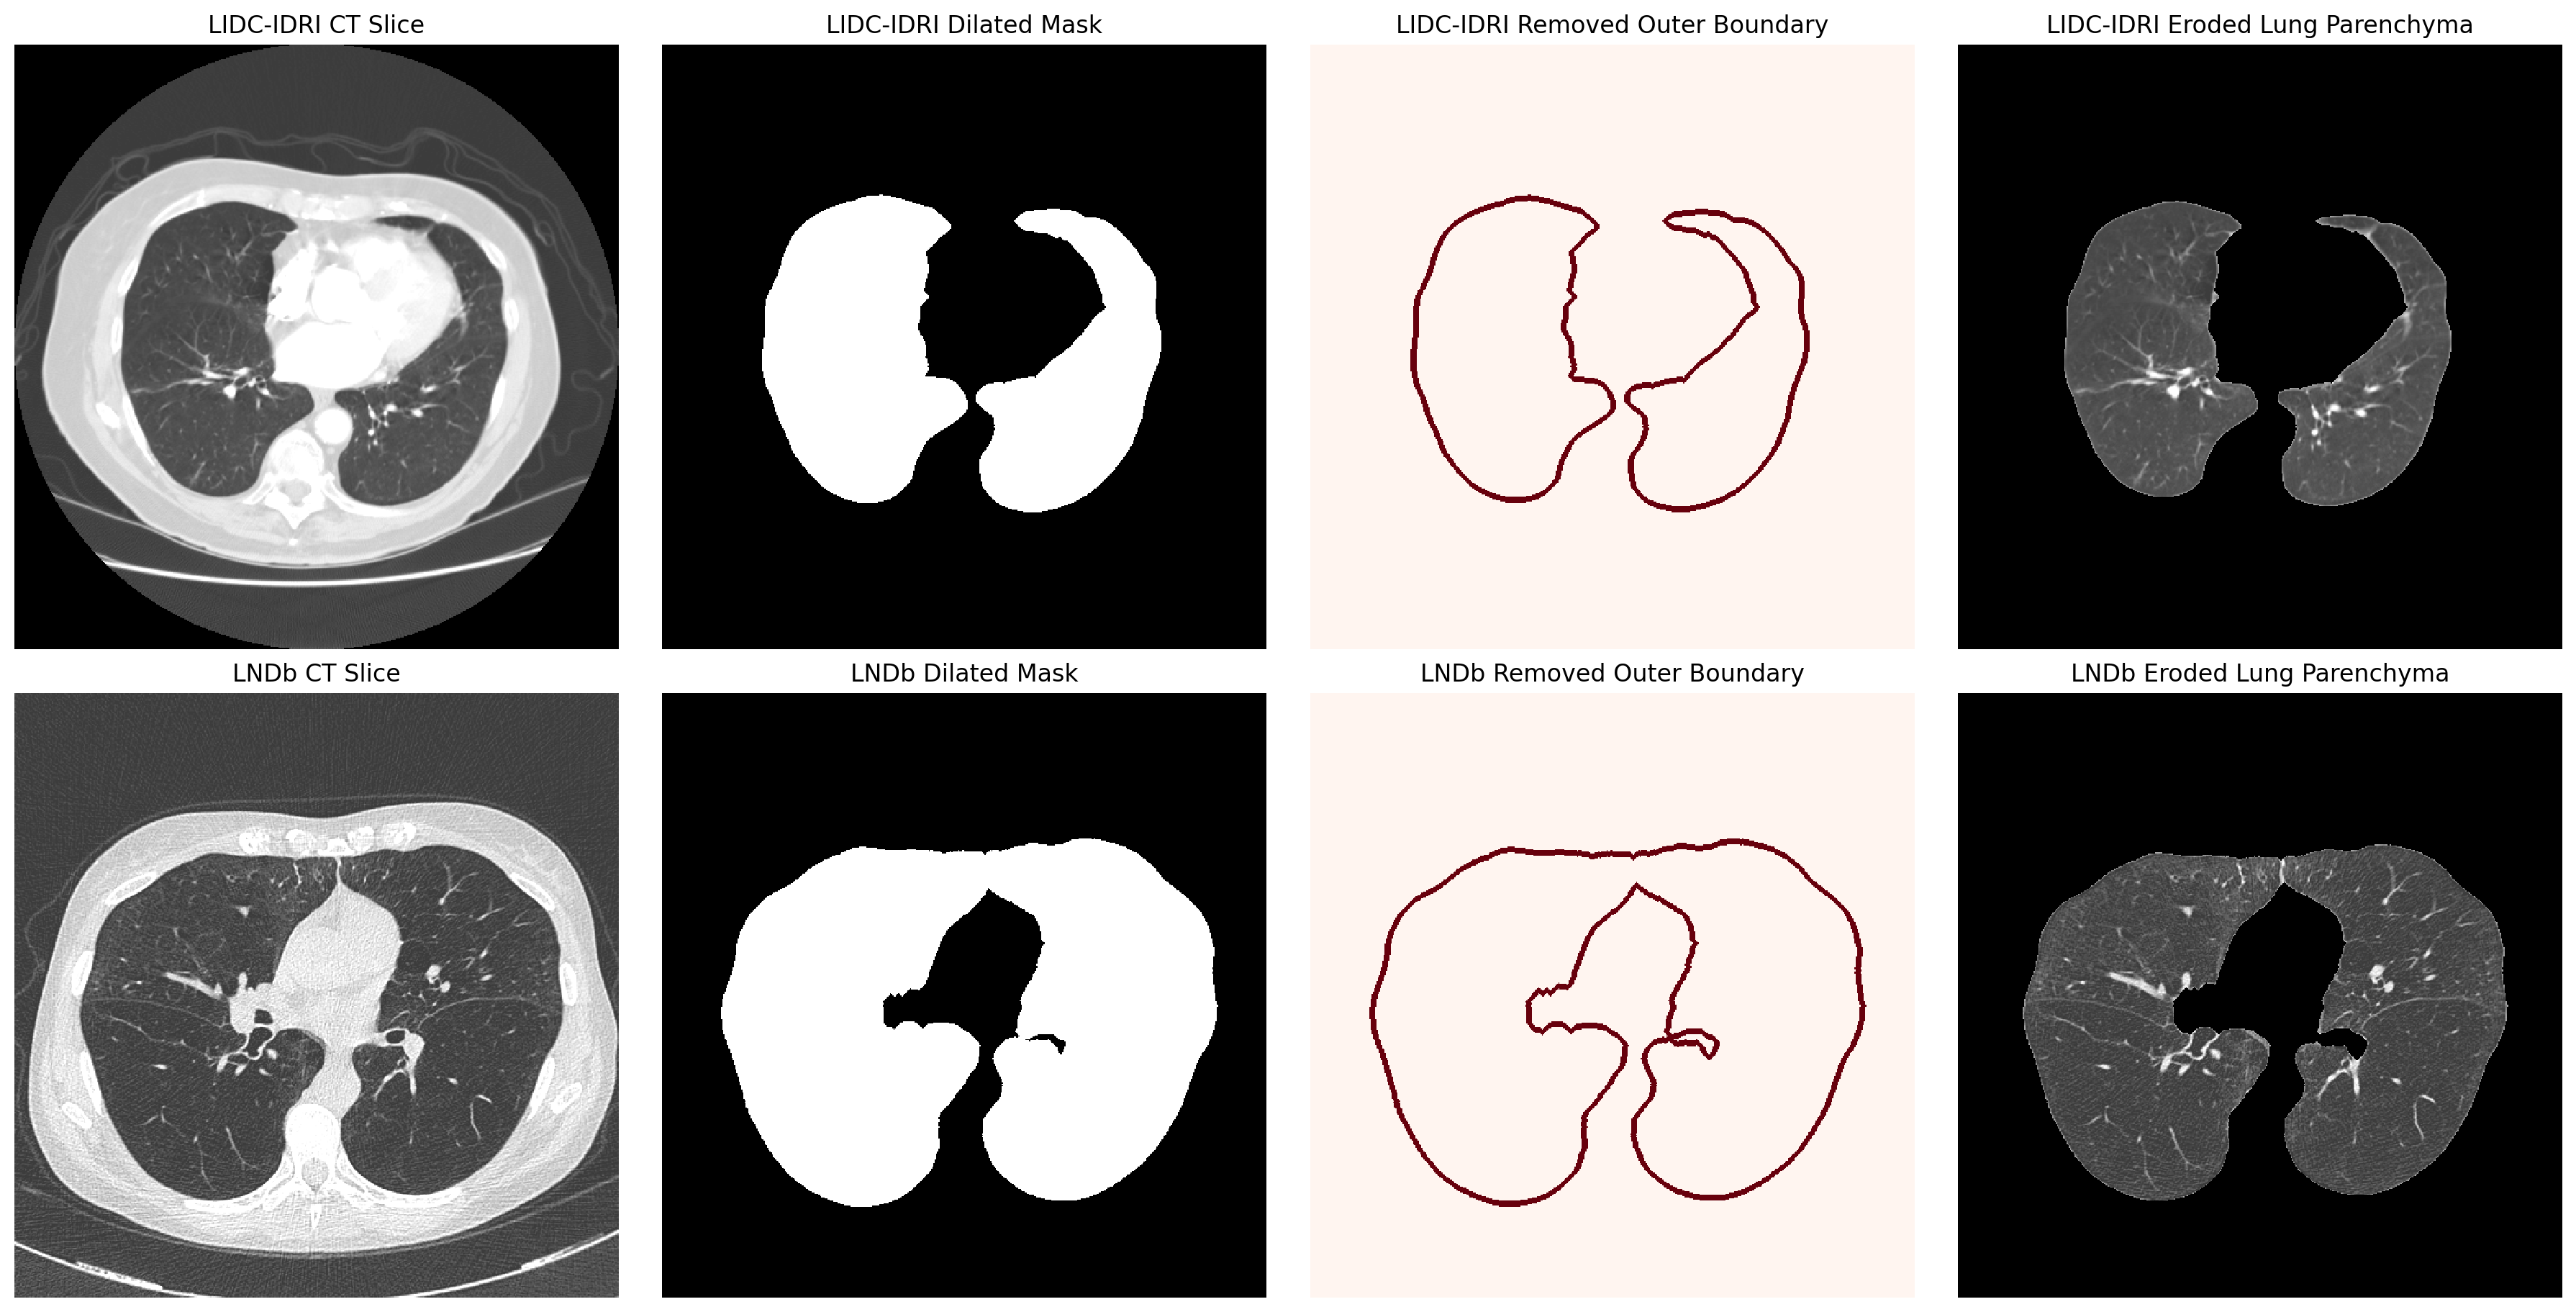

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)

for row, (dataset_name, (_, slice_image, stage_masks, _)) in enumerate(
    segmentation_results.items()
):
    dilated_mask = stage_masks["7. Binary dilation"]
    eroded_mask = eroded_masks[dataset_name]
    removed_outer_boundary = dilated_mask & ~eroded_mask
    eroded_parenchyma = np.where(eroded_mask, slice_image, LUNG_WINDOW[0])

    axes[row, 0].imshow(
        slice_image,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 0].set_title(f"{dataset_name} CT Slice")

    axes[row, 1].imshow(dilated_mask, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"{dataset_name} Dilated Mask")

    axes[row, 2].imshow(removed_outer_boundary, cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].set_title(f"{dataset_name} Removed Outer Boundary")

    axes[row, 3].imshow(
        eroded_parenchyma,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 3].set_title(f"{dataset_name} Eroded Lung Parenchyma")

    for axis in axes[row]:
        axis.axis("off")

plt.show()

# Step 4: Median Filtering

Apply a `(1, 3, 3)` median filter to the original HU volumes. This reduces noise within each axial slice without mixing information between adjacent slices.

In [15]:
median_filtered_volumes = OrderedDict()

for dataset_name, volume in ct_volumes.items():
    median_filtered_volumes[dataset_name] = ndi.median_filter(
        volume,
        size=MEDIAN_FILTER_SIZE,
    )

**Visualization Before and After Median Filtering**

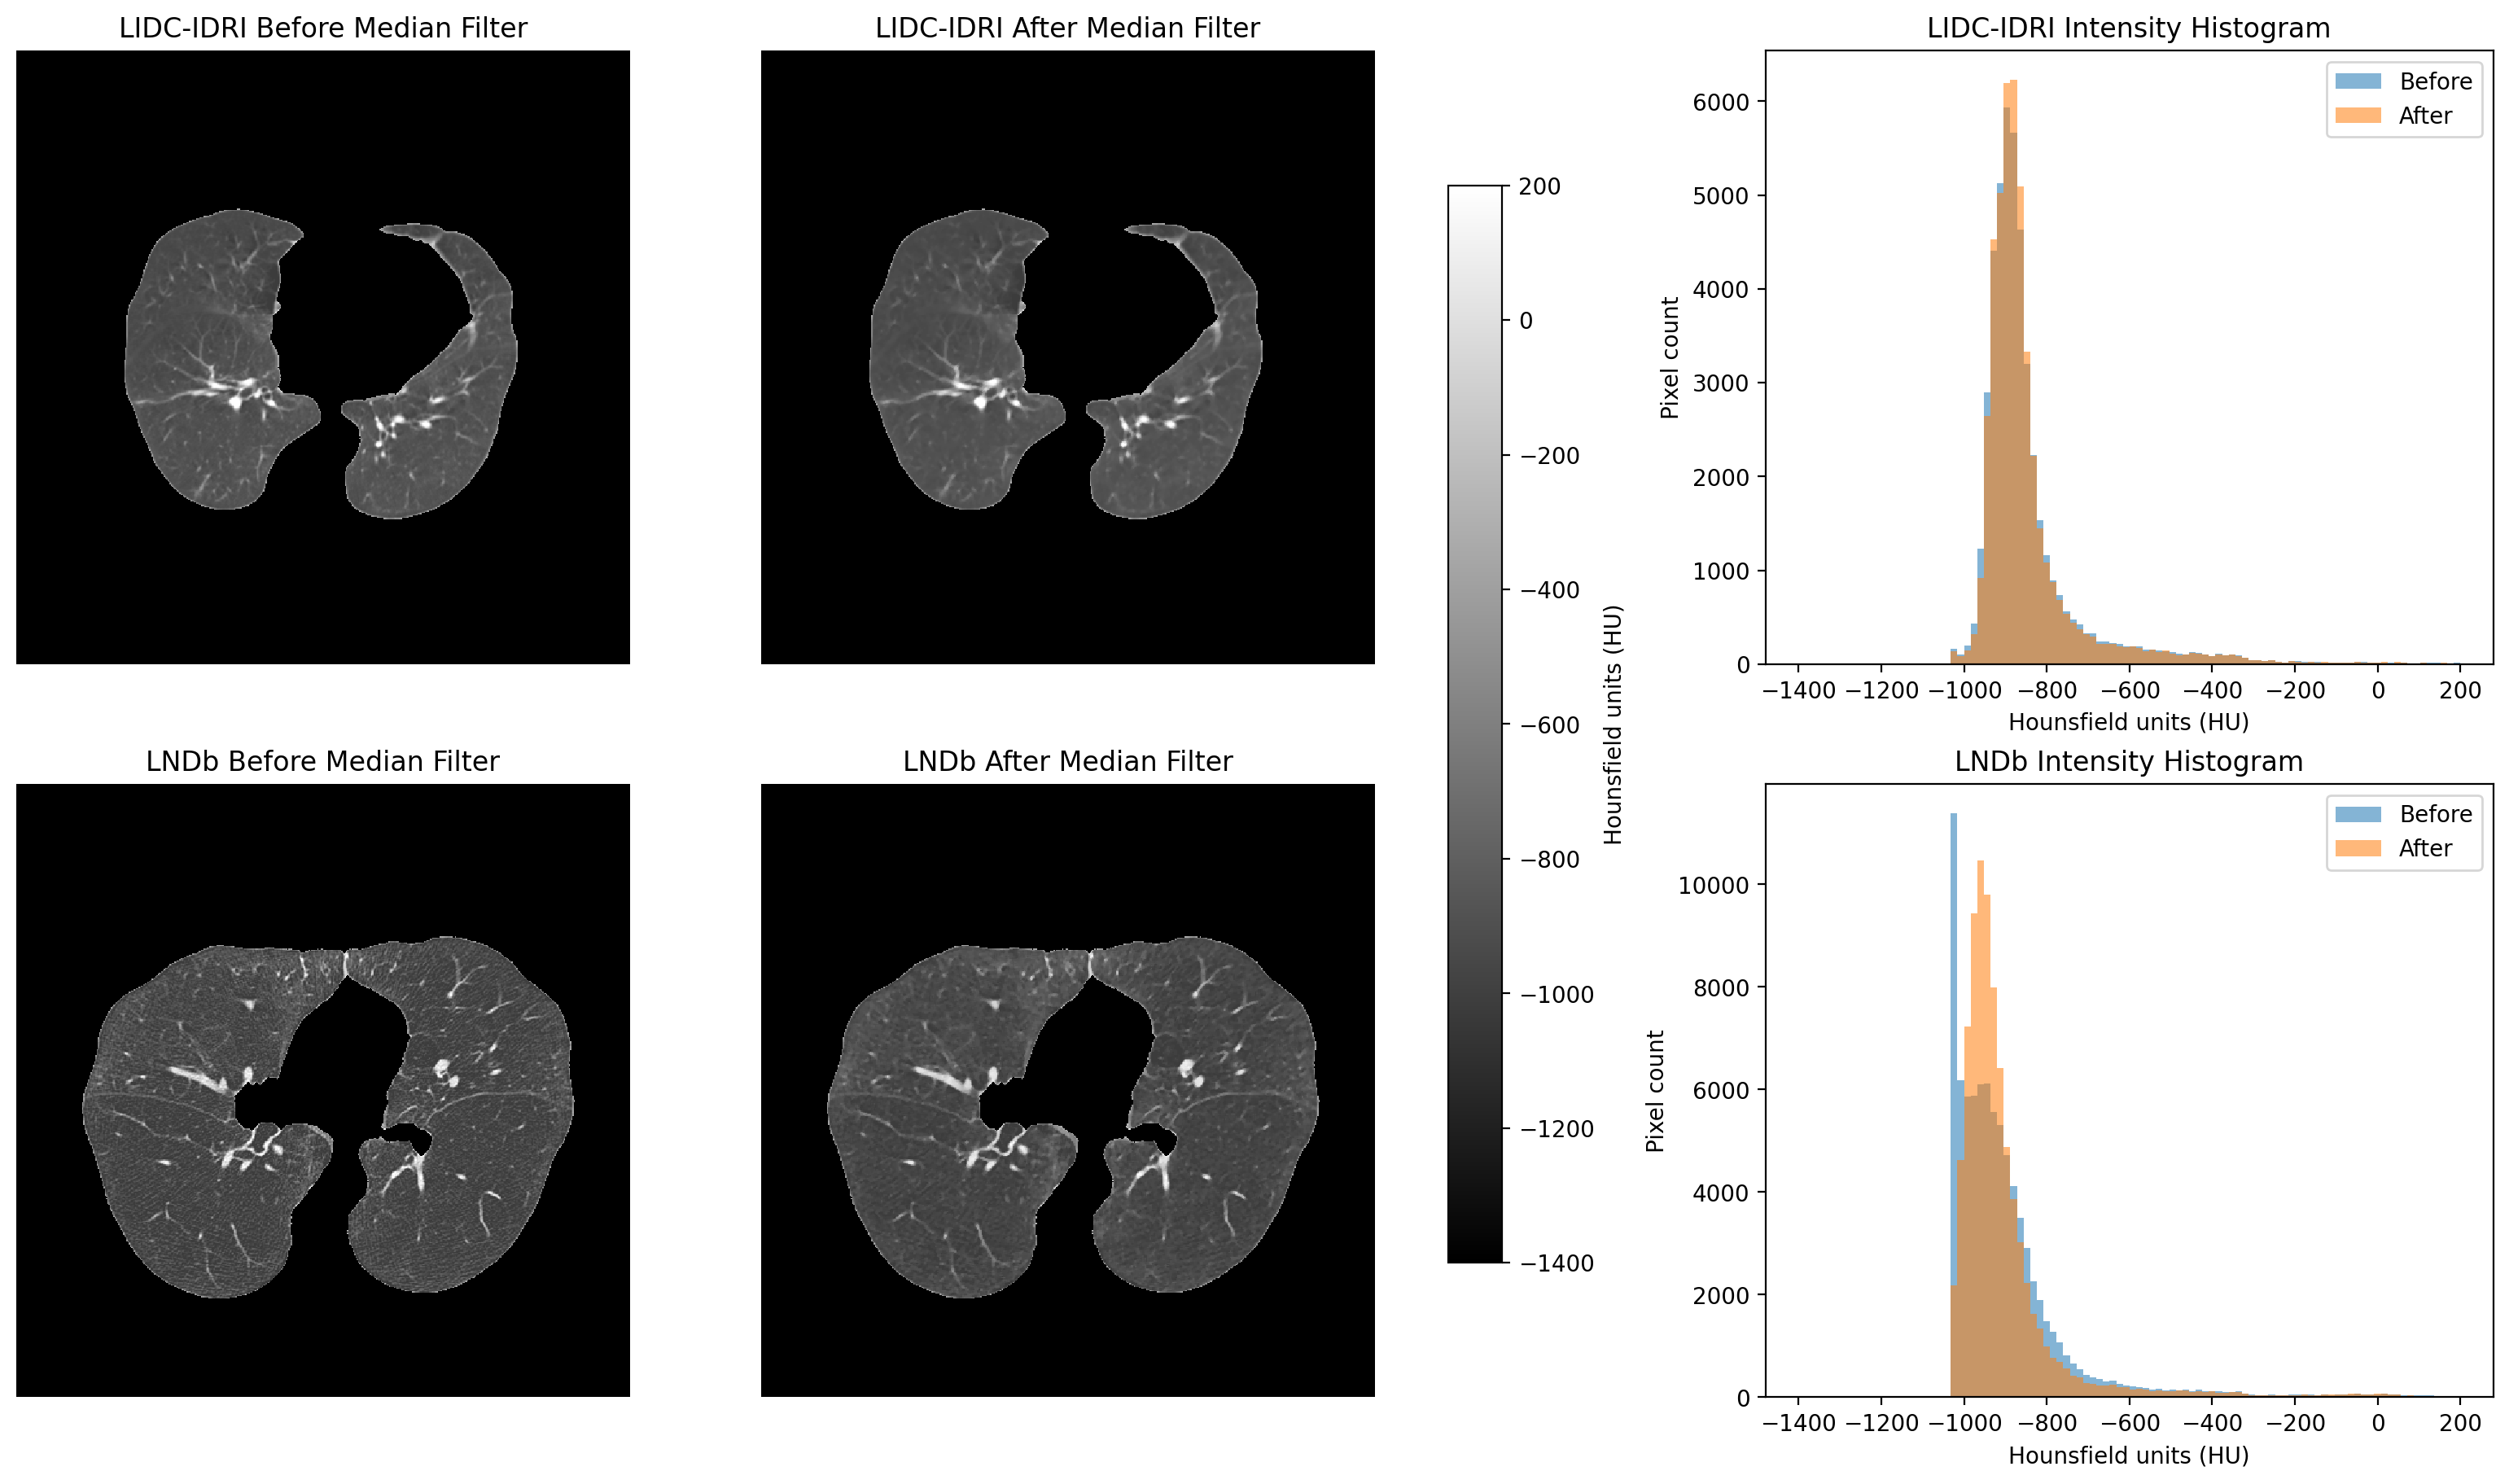

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for row, (dataset_name, (slice_index, slice_image, _, _)) in enumerate(
    segmentation_results.items()
):
    final_mask = eroded_masks[dataset_name]
    filtered_slice = median_filtered_volumes[dataset_name][slice_index]

    original_parenchyma = np.where(final_mask, slice_image, LUNG_WINDOW[0])
    filtered_parenchyma = np.where(final_mask, filtered_slice, LUNG_WINDOW[0])

    axes[row, 0].imshow(
        original_parenchyma,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 0].set_title(f"{dataset_name} Before Median Filter")

    filtered_image = axes[row, 1].imshow(
        filtered_parenchyma,
        vmin=LUNG_WINDOW[0],
        vmax=LUNG_WINDOW[1],
    )
    axes[row, 1].set_title(f"{dataset_name} After Median Filter")

    # Compare only intensities located inside the eroded lung mask.
    axes[row, 2].hist(
        slice_image[final_mask],
        bins=100,
        range=LUNG_WINDOW,
        alpha=0.55,
        label="Before",
    )
    axes[row, 2].hist(
        filtered_slice[final_mask],
        bins=100,
        range=LUNG_WINDOW,
        alpha=0.55,
        label="After",
    )
    axes[row, 2].set_title(f"{dataset_name} Intensity Histogram")
    axes[row, 2].set_xlabel("Hounsfield units (HU)")
    axes[row, 2].set_ylabel("Pixel count")
    axes[row, 2].legend()

for axis in axes[:, :2].ravel():
    axis.axis("off")

fig.colorbar(
    filtered_image,
    ax=axes[:, :2].ravel().tolist(),
    shrink=0.8,
    label="Hounsfield units (HU)",
)
plt.show()

# Step 5: Lung Windowing and Float32 Normalization

Apply a lung window with a level of **-600 HU** and width of **1600 HU** to the median-filtered volumes. Values are clipped to **[-1400, 200] HU** and normalized to `float32` in the range `[0, 1]`. The eroded lung mask is then applied to produce the final displayed lung parenchyma.

In [17]:
def window_and_normalize_ct(
    ct: np.ndarray,
    window_level: float,
    window_width: float,
) -> np.ndarray:
    lower_bound = window_level - (window_width / 2.0)
    upper_bound = window_level + (window_width / 2.0)

    # Convert before normalization to avoid integer arithmetic.
    ct_float = ct.astype(np.float32, copy=False)
    ct_windowed = np.clip(ct_float, lower_bound, upper_bound)
    ct_normalized = (
        (ct_windowed - lower_bound)
        / (upper_bound - lower_bound)
    )

    return ct_normalized.astype(np.float32, copy=False)


normalized_float32_volumes = OrderedDict()

for dataset_name, volume in median_filtered_volumes.items():
    normalized_float32_volumes[dataset_name] = window_and_normalize_ct(
        ct=volume,
        window_level=WINDOW_LEVEL,
        window_width=WINDOW_WIDTH,
    )
    normalized_volume = normalized_float32_volumes[dataset_name]
    print(
        f"{dataset_name}: shape={normalized_volume.shape} | "
        f"dtype={normalized_volume.dtype} | "
        f"range=[{normalized_volume.min():.1f}, {normalized_volume.max():.1f}]"
    )

LIDC-IDRI: shape=(133, 512, 512) | dtype=float32 | range=[0.0, 1.0]
LNDb: shape=(328, 512, 512) | dtype=float32 | range=[0.2, 1.0]


**Normalized CT Volume and Intensity Histogram**

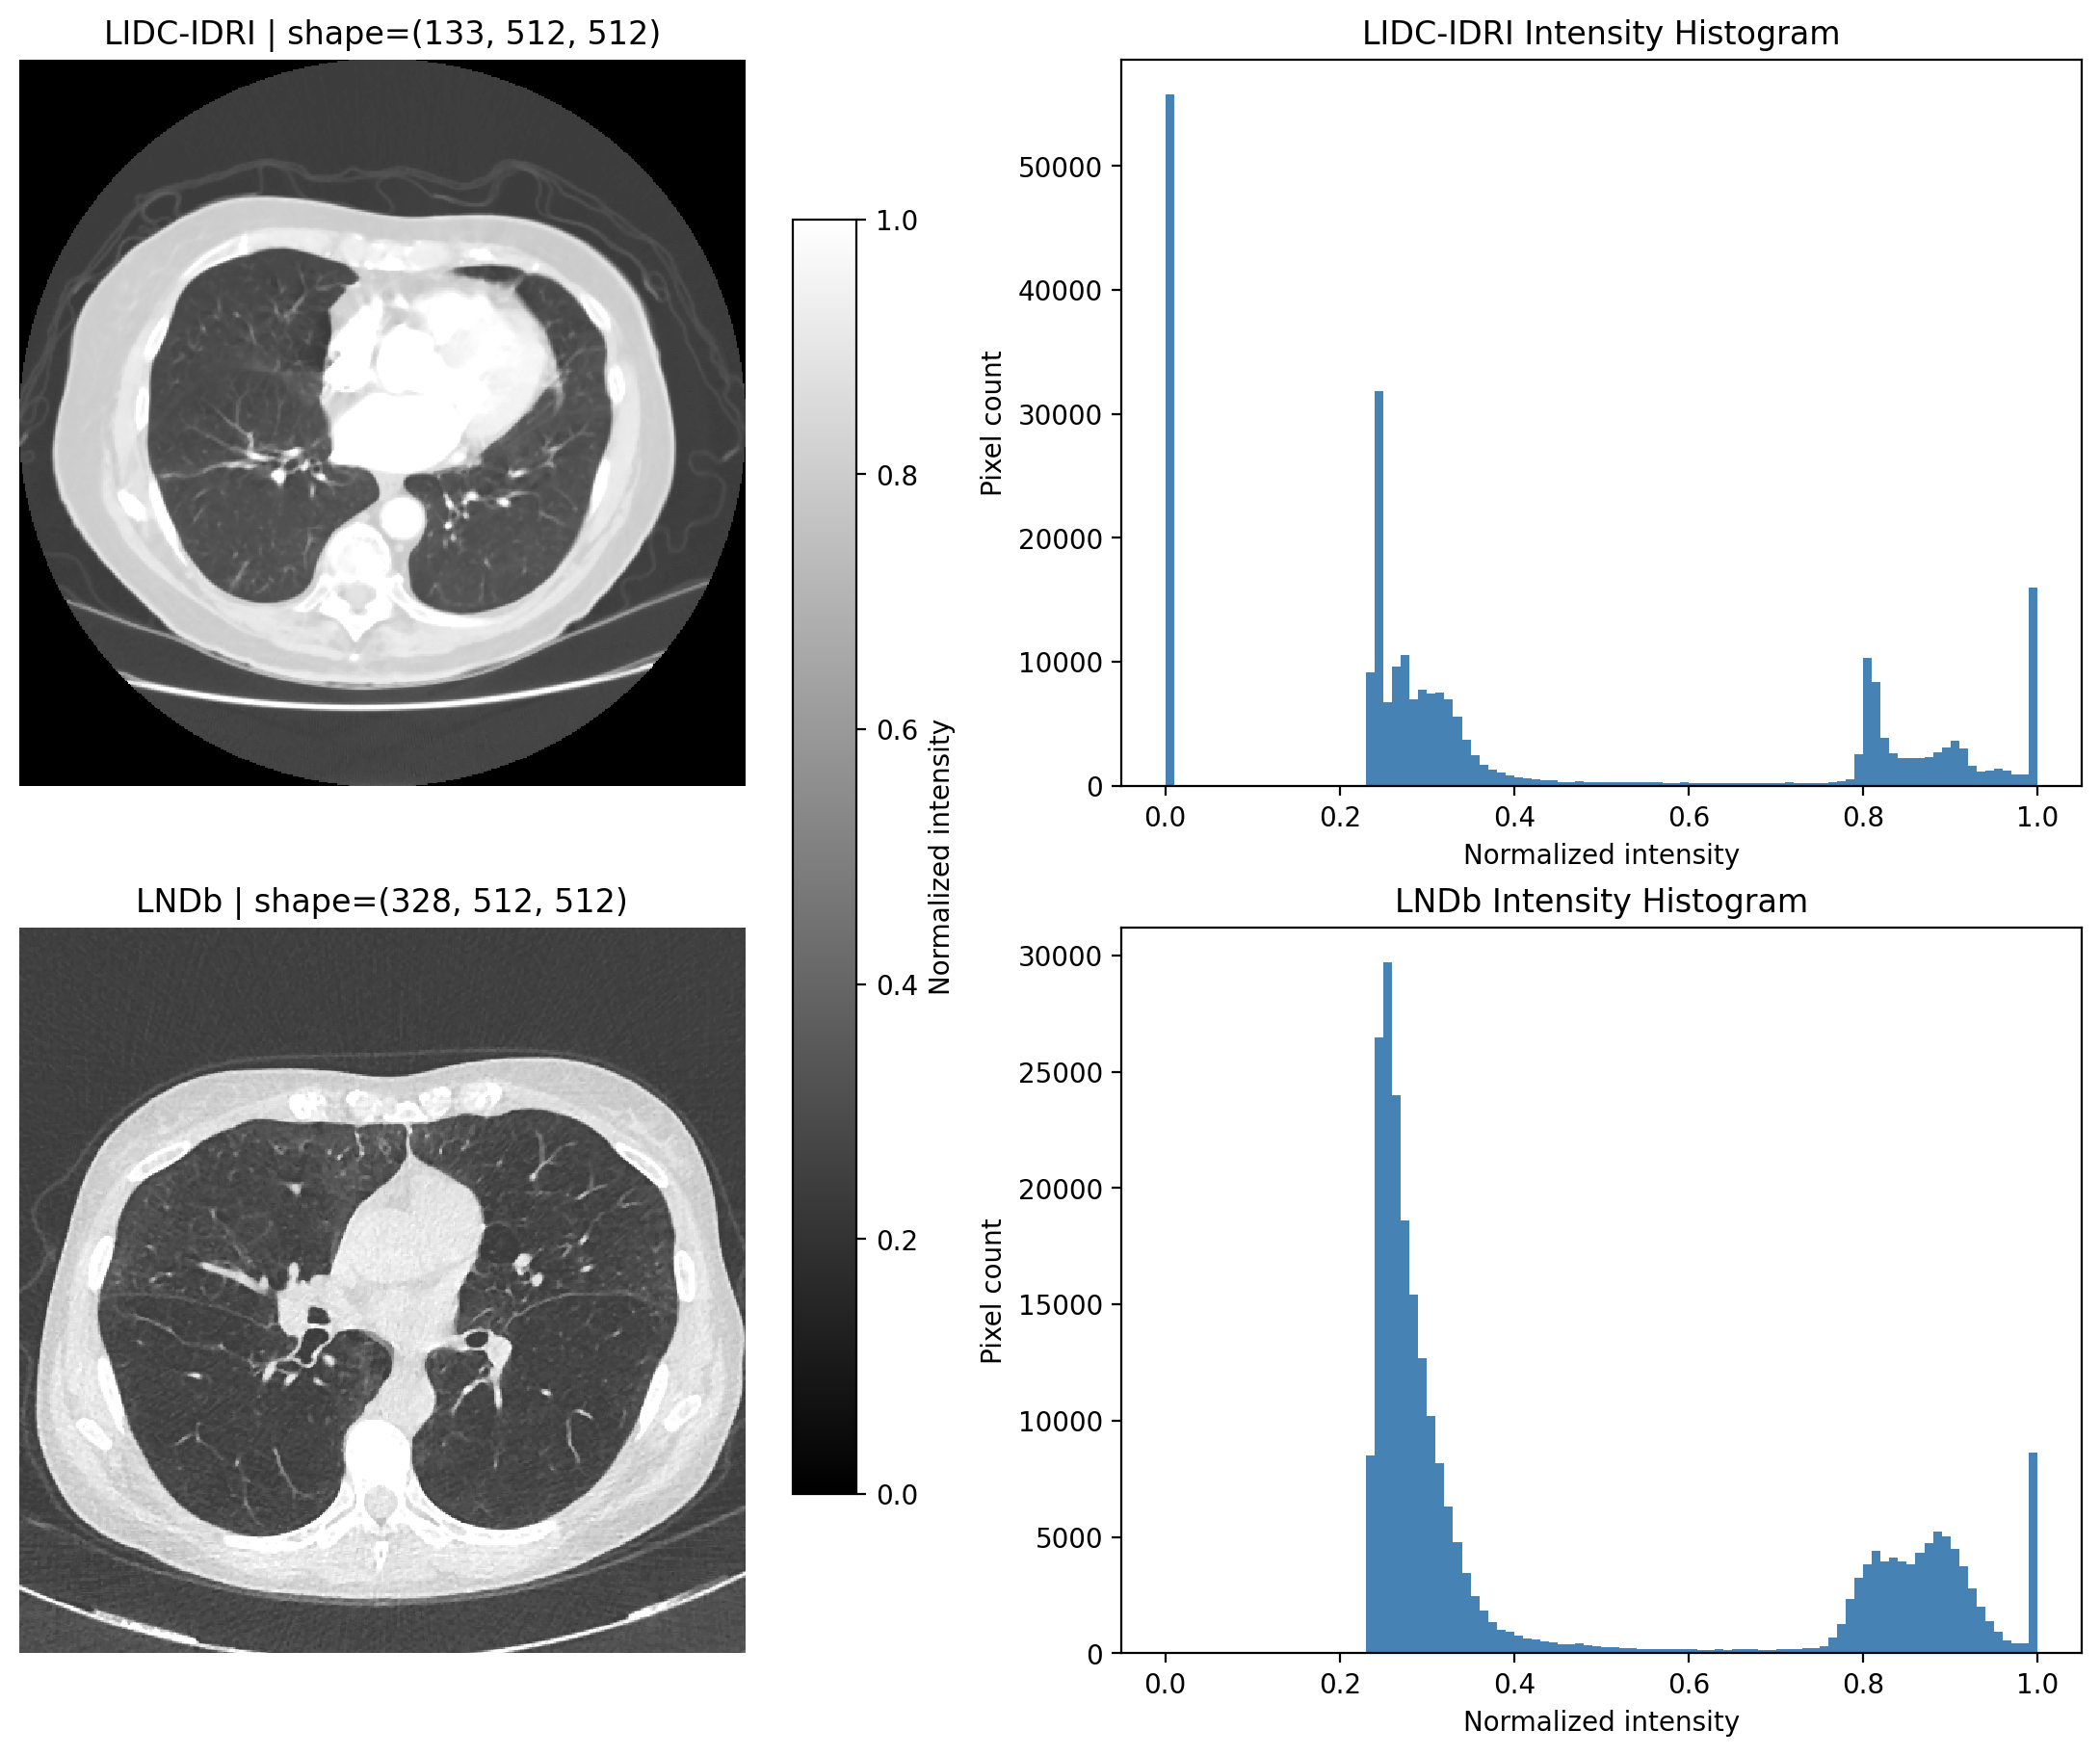

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for row, (dataset_name, volume) in enumerate(
    normalized_float32_volumes.items()
):
    image_axis, histogram_axis = axes[row]
    middle_slice = volume.shape[0] // 2
    slice_image = volume[middle_slice]

    image = image_axis.imshow(slice_image, vmin=0.0, vmax=1.0)
    image_axis.set_title(f"{dataset_name} | shape={volume.shape}")
    image_axis.axis("off")

    histogram_axis.hist(
        slice_image.ravel(),
        bins=100,
        range=(0.0, 1.0),
        color="steelblue",
    )
    histogram_axis.set_title(f"{dataset_name} Intensity Histogram")
    histogram_axis.set_xlabel("Normalized intensity")
    histogram_axis.set_ylabel("Pixel count")

fig.colorbar(image, ax=axes[:, 0], shrink=0.8, label="Normalized intensity")
plt.show()

**Final Normalized Lung Parenchyma and Intensity Histogram**

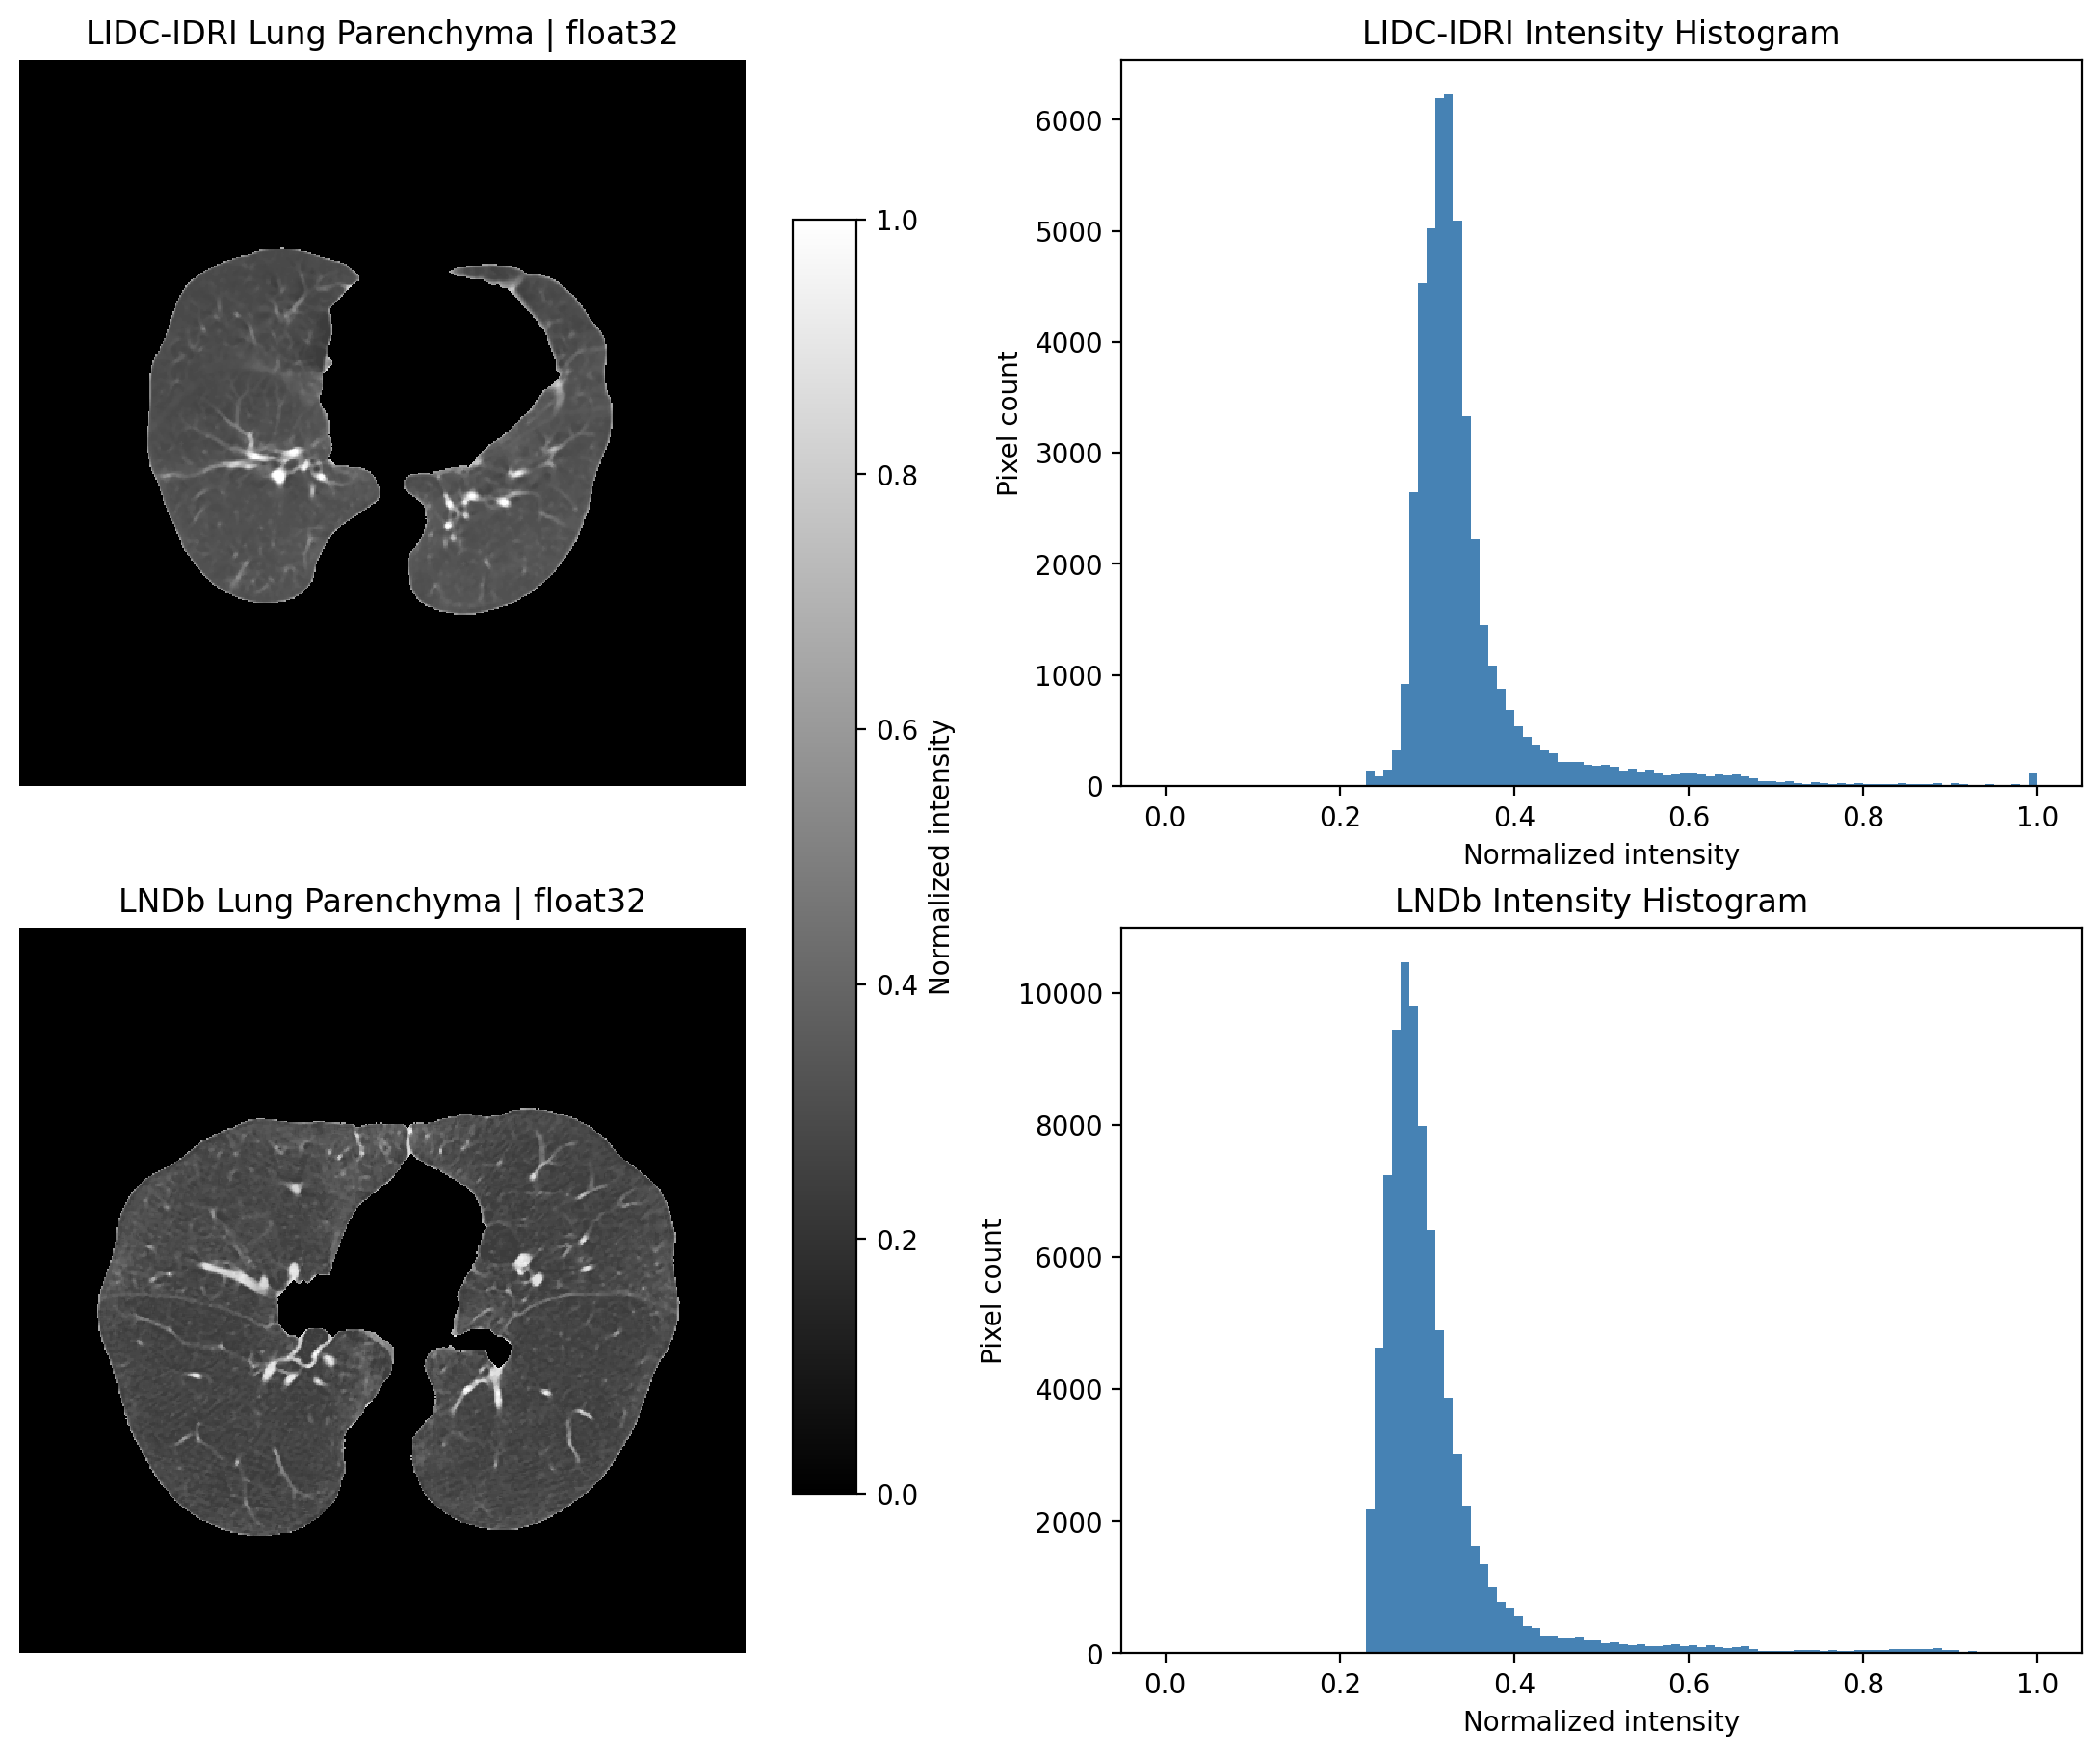

In [19]:
final_normalized_slices = OrderedDict()
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for row, (dataset_name, (slice_index, _, _, _)) in enumerate(
    segmentation_results.items()
):
    final_mask = eroded_masks[dataset_name]
    normalized_slice = normalized_float32_volumes[dataset_name][slice_index]

    # Set every pixel outside the eroded lung mask to zero.
    normalized_parenchyma = np.where(
        final_mask,
        normalized_slice,
        np.float32(0.0),
    ).astype(np.float32, copy=False)
    final_normalized_slices[dataset_name] = normalized_parenchyma

    image_axis, histogram_axis = axes[row]
    image = image_axis.imshow(
        normalized_parenchyma,
        vmin=0.0,
        vmax=1.0,
    )
    image_axis.set_title(
        f"{dataset_name} Lung Parenchyma | {normalized_parenchyma.dtype}"
    )
    image_axis.axis("off")

    # Exclude the zero background from the final intensity histogram.
    histogram_axis.hist(
        normalized_slice[final_mask],
        bins=100,
        range=(0.0, 1.0),
        color="steelblue",
    )
    histogram_axis.set_title(f"{dataset_name} Intensity Histogram")
    histogram_axis.set_xlabel("Normalized intensity")
    histogram_axis.set_ylabel("Pixel count")

fig.colorbar(image, ax=axes[:, 0], shrink=0.8, label="Normalized intensity")
plt.show()